In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e


In [3]:
from pairinteraction.visualization.colormaps import alphamagma
import os
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 2, 2
l1_1, l2_1 = 1, 3
j1_0, j2_0 = 3/2, 5/2


if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()  

energy_unit = 'MHz'
    

In [4]:
n_dif=2
ldif=1
jdif=1
def get_system_pair_list_r(
    ket1: pi.SystemAtom, ket2: pi.SystemAtom, rs: np.ndarray, erange, theta, b, e
) -> list[pi.SystemPair]:


    basis1 = pi.BasisAtom(ket1.species, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))
    basis2 = pi.BasisAtom(ket2.species, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif, ket2.j+jdif))



    system1, system2 = pi.SystemAtom(basis1).set_magnetic_field([0,0,b], unit='G').set_electric_field([0,0,e], unit='V/cm').set_diamagnetism_enabled(True), pi.SystemAtom(basis2).set_magnetic_field([0,0,b], unit='G').set_electric_field([0,0,e], unit='V/cm').set_diamagnetism_enabled(True)


    pi.diagonalize([system1, system2])

    pair_energy = system1.get_corresponding_energy(ket1, unit=energy_unit) + system2.get_corresponding_energy(ket2, unit=energy_unit)
    min_energy, max_energy = pair_energy - erange, pair_energy + erange

    pair_basis = pi.BasisPair(
            [system1, system2], energy=(min_energy, max_energy), energy_unit=energy_unit
        )

    pair_systems = []
    for i, r in enumerate(rs):
                
        # print(f'pair energy = {pair_energy}{energy_unit}')
            
        
        pair_systems.append(
            pi.SystemPair(pair_basis)
            .set_distance(r, unit='um', angle_degree=theta)
            )
        states_num = pair_basis.number_of_states
        # print(f"Number of two-atom basis states: {pair_basis.number_of_states}")


    # Diagonalize the systems in parallel
    pi.diagonalize(
        pair_systems,
        diagonalizer="lapacke_evd",
        energy_range=(min_energy, max_energy),
        energy_range_unit=energy_unit,
    )
    
    energies = [system.get_eigenenergies(unit = energy_unit) - pair_energy for system in pair_systems]

    return pair_systems, states_num, energies

In [5]:
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)

   Unnamed: 0  n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  ...  \
0           3    45     2   1.5    51     2   2.5    46     1   0.5  ...   
1           2    45     2   1.5    51     2   2.5    46     1   0.5  ...   
2           6    47     2   1.5    54     2   2.5    48     1   1.5  ...   
3           4    53     2   1.5    60     2   2.5    54     1   0.5  ...   
4           5    53     2   1.5    60     2   2.5    54     1   0.5  ...   
5           8    54     2   1.5    62     2   2.5    55     1   1.5  ...   
6           0    59     2   1.5    57     2   2.5    61     1   0.5  ...   
7           1    59     2   1.5    57     2   2.5    61     1   0.5  ...   
8           7    61     2   1.5    69     2   2.5    62     1   0.5  ...   

   asymmetry 4um  energy 4um  asymmetry 3um  energy 3um  energy_Rb 3um  \
0    -583.190951  -34.489343     -28.409727  -93.572437     -11.269094   
1    -472.400891  -34.617153     -47.273165  -94.268968      -4.130529   
2     -89.981441 

In [24]:
channel = 3
c = channels.loc[channel]
# set atom properties
n1_0, l1_0, j1_0 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2_0, l2_0, j2_0 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 
mj1_0s, mj2_0s = np.arange(-j1_0, j1_0+1), np.arange(-j2_0, j2_0+1)
f1_0, f2_0 = 1, 1

n1_1, l1_1, j1_1 = int(c['n1_1']), int(c['l1_1']), c['j1_1']
n2_1, l2_1, j2_1 =  int(c['n2_1']), int(c['l2_1']), c['j2_1']
f1_1, f2_1 = 1, 1

ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=j1_0, j=j1_0)
ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=j2_0, j=j2_0)
ket1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=j1_1)
ket2_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=j2_1)
ket1_energy = ket1.get_energy(unit=energy_unit)
ket2_energy = ket2.get_energy(unit=energy_unit)

defect = c['defect']
btunes = np.unique(magTune_import(atom1, n1_0, l1_0, j1_0, atom2, n2_0, l2_0, j2_0, l1_1, l2_1))


bfield = 0  # Gauss
erange = abs(defect*1000)
bs = np.array([0])
bs = np.append(bs, np.array(btunes))
print(defect)

rs = np.linspace(1, 40, 200)
rs=[20]
rs = np.append(rs, [5000])
e=0.0964824120603015
# b=bs[7]
b=30
thetas = [0]
system_pairs_dict: dict[float, list[pi.SystemPair]] = {}
system_pairs_dict_inter = {}
system_pairs_dict_Rb = {}
system_pairs_dict_Cs = {}
energies_inter_dict = {}
energies_intra_Rb_dict = {}
energies_intra_Cs_dict = {}

Magnetic file doesn't exist
-4.618507926352301


In [25]:
ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=-j1_0), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=-j2_0)

for theta in thetas:
    while True:
        try:
            pairs = get_system_pair_list_r(ket1, ket2, rs, erange, theta, b, e)
            system_pairs = pairs[0]
            states_num = pairs[1]
            energies = pairs[2]


            
            system_pairs_dict_inter.update({f'{theta}{b}': system_pairs})
            energies_inter_dict.update({f'{theta}{b}' : energies})
            break
        except RuntimeError: # Replace Exception with something more specific.
            continue


In [27]:
import os
datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\'
if not os.path.exists(datapath + 'inter'):
    os.makedirs(datapath + 'inter')

print(ket1)

energies_inter_dict.update({'rs' : rs})
    

|Rb:53,D_3/2,3/2⟩


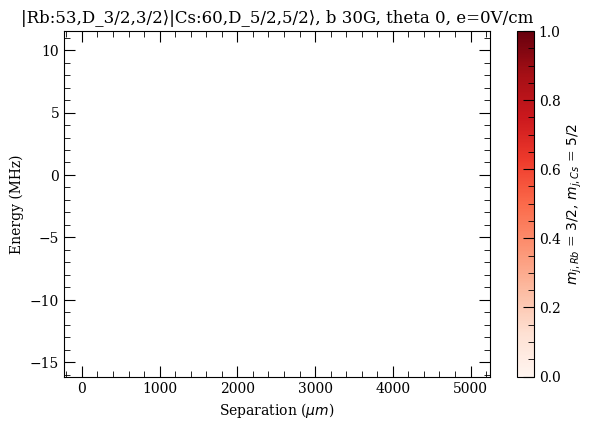

In [28]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']


for theta in thetas:
    for mj1 in mj1_0s[-1:]:
        for mj2 in mj2_0s[-1:]:
            import os

            ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=mj1), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=mj2)

            system_pairs = system_pairs_dict_inter[f'{theta}{b}']


            overlaps_inter = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pairs]


            energies_inter = energies_inter_dict[f'{theta}{b}']

            rs = energies_inter_dict['rs']


            # print(energies_inter)
            
                    
            # 2. Build the RGBA array: (N, 4)

            fig, ax = plt.subplots(ncols=1, figsize=(6, 4))

            plt.tight_layout()
            plt.title(fr'{str(ket1)}{str(ket2)}, b {b}G, theta {theta}, e={0}V/cm')
            energy_lim = abs(defect + defect*2)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            plt.ylim(min_energy, max_energy)
            # plt.xlim(2, 2.7)
            plt.ylabel(f"Energy ({energy_unit})")
            plt.xlabel(fr"Separation ($\mu m$)")
            # ax.plot(e_fields_sub, energies)

            # for x, es in zip(rs, energies_inter):
            #     plt.plot([x] * len(es), es, c='.7', ls="None", marker=".", ms=1, zorder=-1)
            r, energy, overlap = [], [], []
            min_overlap = 0.01
            for x, es, os in zip(rs, energies_inter, overlaps_inter):
                inds = np.argwhere(os > min_overlap).flatten()
                inds = inds[np.argsort(os[inds])]
                if len(inds) > 0:
                    r.extend([x] * len(es[inds]))
                    energy.extend(es[inds])
                    overlap.extend(os[inds])

                    rgba = np.zeros((len(es[inds]), 4))
                    base_rgb = mcolors.to_rgb(colours[0])
                    rgba[:, :3] = base_rgb
                    rgba[:, 3] = os[inds]

                    scat = plt.scatter(
                        [x] * len(es[inds]),
                        es[inds],
                        c=os[inds],
                        s=10,
                        vmin=0,
                        vmax=1,
                        marker='.',
                        cmap = 'Reds'
                    )
            overlapped_inter = {'r' : np.array(r), 'energy' : np.array(energy), 'overlap' : np.array(overlap)}
            fig.colorbar(scat, ax=ax, label=fr"$m_{{j,Rb}}$ = ${int(mj1*2)}/2$, $m_{{j,Cs}}$ = ${int(mj2*2)}/2$")

            plt.show()
            pd.DataFrame(overlapped_inter).to_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {b}G, e{e}Vcm.csv')

            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            fig.savefig(figpath + f'b {b}G theta{theta} e{e}Vcm mjs{mj1},{mj2}.png')
            plt.close()


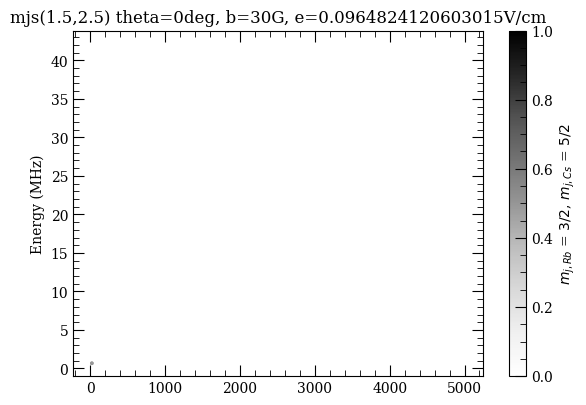

[np.float64(111.05262732505798), np.float64(-0.6800539493560791), np.float64(0.6656951904297443), np.float64(111.05338335037231)]


In [22]:
datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\'

import os
datapath_field = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\field-corrected\\'
if not os.path.exists(datapath_field + 'inter'):
    os.makedirs(datapath_field + 'inter')
if not os.path.exists(datapath_field + 'intra Rb'):
    os.makedirs(datapath_field + 'intra Rb')
if not os.path.exists(datapath_field + 'intra Cs'):
    os.makedirs(datapath_field + 'intra Cs')
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\angular\\inter intra\\polar\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)
# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']
# thetas = [0, 45, 90]
# system_atom = system_atom_dict[efield]

for theta in thetas:
    for mj1 in mj1_0s[-1:]:
        for mj2 in mj2_0s[-1:]:
            # print(overlapped_inter)
            overlapped_inter = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {b}G, e{e}Vcm.csv')


            # print(overlapped_inter_big['energy'])
            fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
            cutoff = 1
            
            ax.set_ylabel(f"Energy ({energy_unit})")
            plt.tight_layout()
            plt.title(fr'mjs({mj1},{mj2}) theta={theta}deg, b={np.round(b,2)}G, e={e}V/cm')
            energy_lim = abs(defect*10)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            plt.ylim(-1, max_energy)
            energies = {'energy' : [], 'r' : [], 'overlap' : []}
            energy = [e - overlapped_inter['energy'].iloc[-1] for e in overlapped_inter['energy'][:-cutoff]]
            energies['energy'] = energy
            energies['r'] = overlapped_inter['r'][:-cutoff]
            energies['overlap'] = overlapped_inter['overlap'][:-cutoff]
            scat = plt.scatter(
                energies['r'],
                abs(np.array(energies['energy'])),
                c=energies['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Greys'
            )
            plt.colorbar(scat, ax=ax, label=fr"$m_{{j,Rb}}$ = ${int(mj1*2)}/2$, $m_{{j,Cs}}$ = ${int(mj2*2)}/2$")

            # print(np.array(energies_Cs['energy']))
            plt.show()
            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            pd.DataFrame(energies).to_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {b}G, e{e}Vcm.csv')

            fig.savefig(figpath + f'theta {theta}deg b{np.round(b,3)}G e{e}Vcm mjs{mj1},{mj2}.png', bbox_inches = 'tight')
            plt.close()
            print(energies['energy'])

fitted


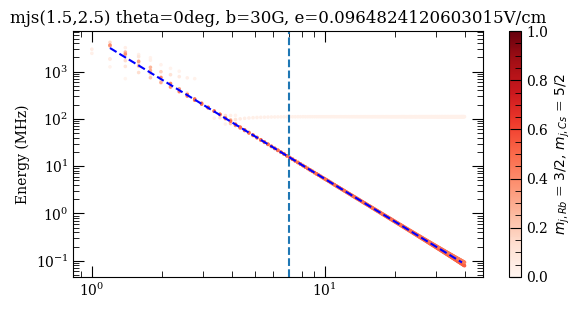

In [59]:
datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\'

import os
datapath_field = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\field-corrected\\'
if not os.path.exists(datapath_field + 'inter'):
    os.makedirs(datapath_field + 'inter')
if not os.path.exists(datapath_field + 'intra Rb'):
    os.makedirs(datapath_field + 'intra Rb')
if not os.path.exists(datapath_field + 'intra Cs'):
    os.makedirs(datapath_field + 'intra Cs')
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\angular\\inter intra\\polar\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)
# ax.set_ylim(-0.01, 0.01)
fitted_datapath =fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\field-corrected\\fitted\\'

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']
# thetas = [0, 45, 90]
# system_atom = system_atom_dict[efield]
e=0.0964824120603015

for theta in thetas:
    for mj1 in mj1_0s[-1:]:
        for mj2 in mj2_0s[-1:]:
            # print(overlapped_inter)
            overlapped_inter = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {b}G, e{e}Vcm.csv')


            # print(overlapped_inter_big['energy'])
            fig, ax = plt.subplots(ncols=1, figsize=(6, 3))

            
            ax.set_ylabel(f"Energy ({energy_unit})")
            plt.tight_layout()
            plt.title(fr'mjs({mj1},{mj2}) theta={theta}deg, b={np.round(b,2)}G, e={e}V/cm')
            energy_lim = abs(defect*10)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            # plt.ylim(-1, max_energy)
            energies = {'energy' : [], 'r' : [], 'overlap' : []}
            energy = [e - overlapped_inter['energy'].iloc[-1] for e in overlapped_inter['energy'][:-5]]
            energies['energy'] = energy
            energies['r'] = overlapped_inter['r'][:-5]
            energies['overlap'] = overlapped_inter['overlap'][:-5]
            scat = plt.scatter(
                energies['r'],
                abs(np.array(energies['energy'])),
                c=energies['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Reds'
            )
            plt.colorbar(scat, ax=ax, label=fr"$m_{{j,Rb}}$ = ${int(mj1*2)}/2$, $m_{{j,Cs}}$ = ${int(mj2*2)}/2$")
            if os.path.exists(fitted_datapath + f'mjs ({mj1}, {mj2}), theta {theta}, b {b}G, e{e}Vcm.csv'):
                print('fitted')
                fitted = pd.read_csv(fitted_datapath + f'mjs ({mj1}, {mj2}), theta {theta}, b {b}G, e{e}Vcm.csv')
                ax.plot(fitted['rs'], fitted['energy'], c='b', linewidth = 1.5, linestyle = 'dashed')
            ax.set_yscale('log')
            ax.set_xscale('log')
            ax.axvline(x=7, linestyle='dashed')
            # print(np.array(energies_Cs['energy']))
            plt.show()
            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            pd.DataFrame(energies).to_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {b}G.csv')

            fig.savefig(figpath + f'theta {theta}deg b{np.round(b,3)}G e{e}Vcm mjs{mj1},{mj2}.png', bbox_inches = 'tight')
            plt.close()

In [44]:
fitted = pd.read_csv(fitted_datapath + f'mjs ({mj1}, {mj2}), theta {theta}, b {b}G, e{e}Vcm.csv')

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


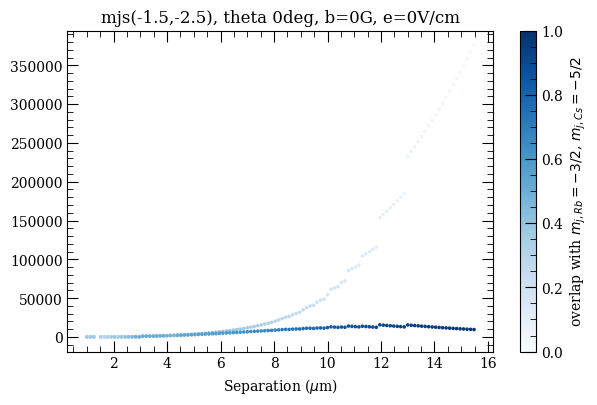

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


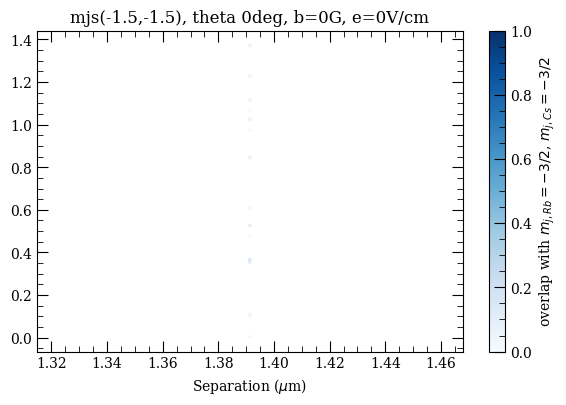

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


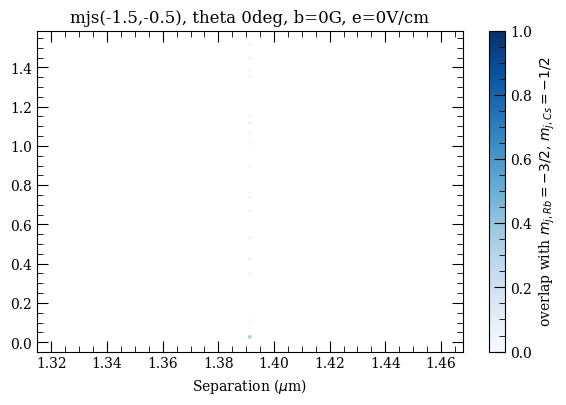

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


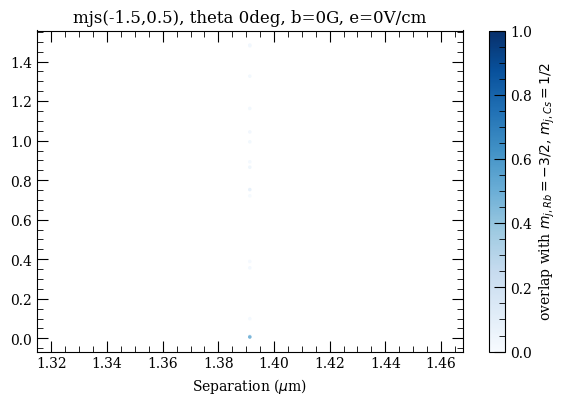

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


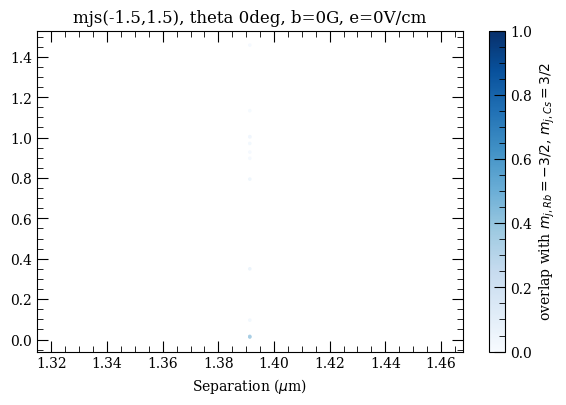

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


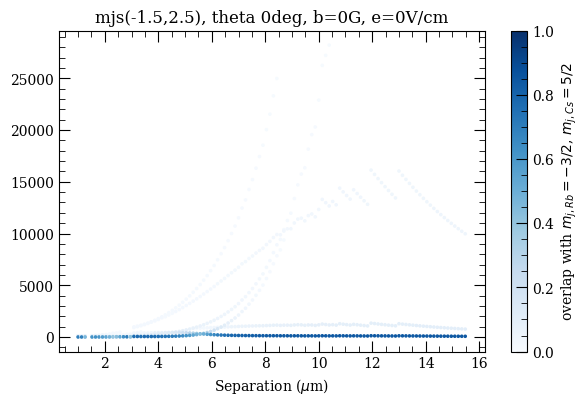

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


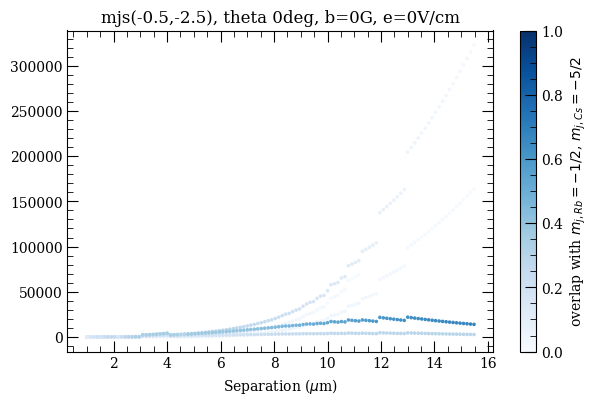

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


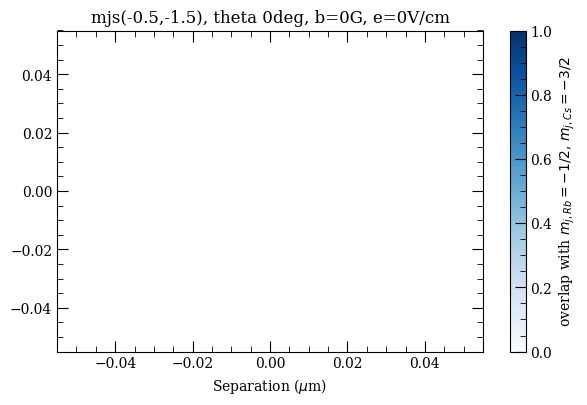

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


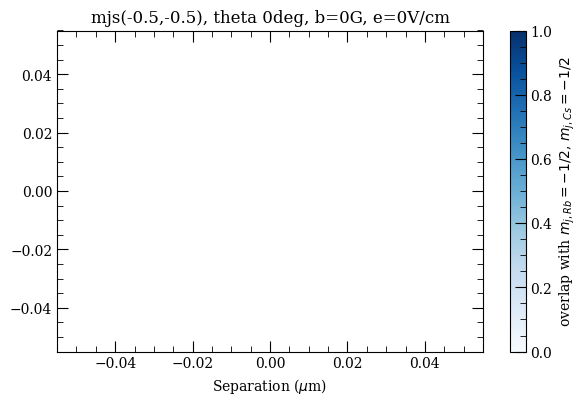

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


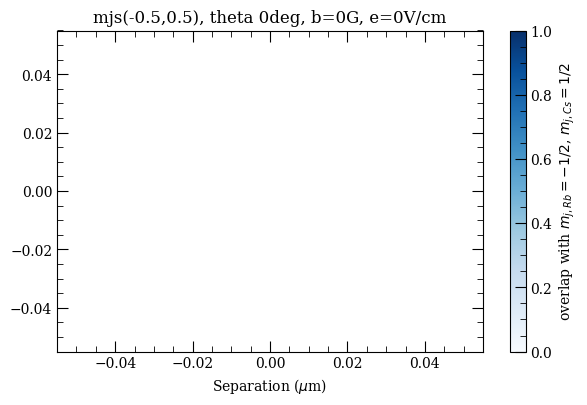

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


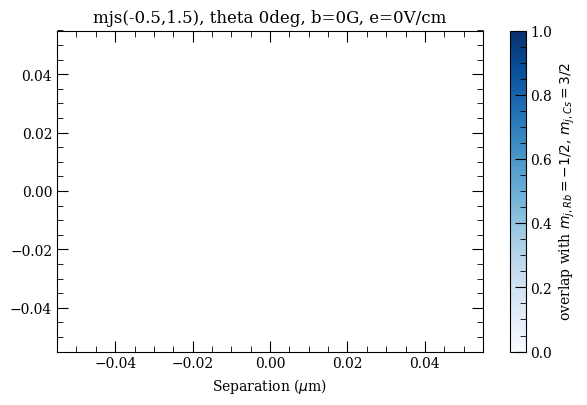

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


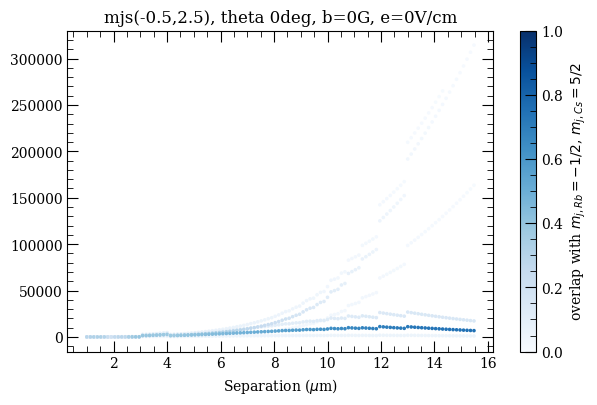

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


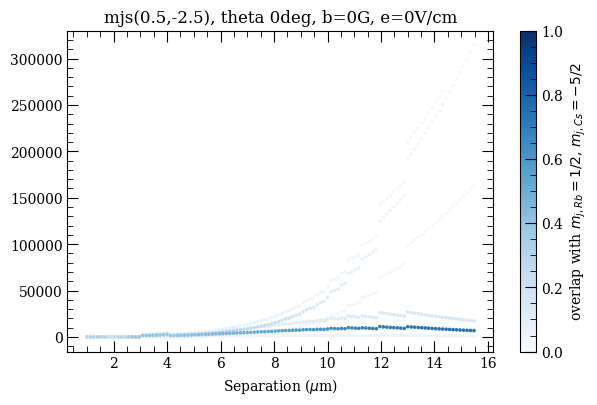

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


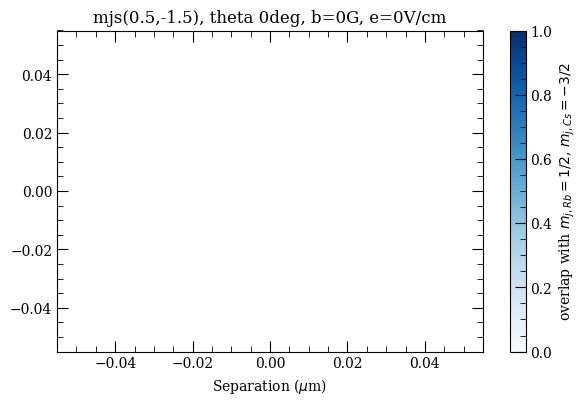

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


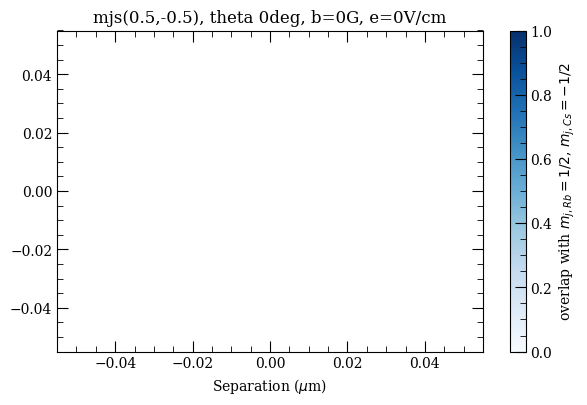

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


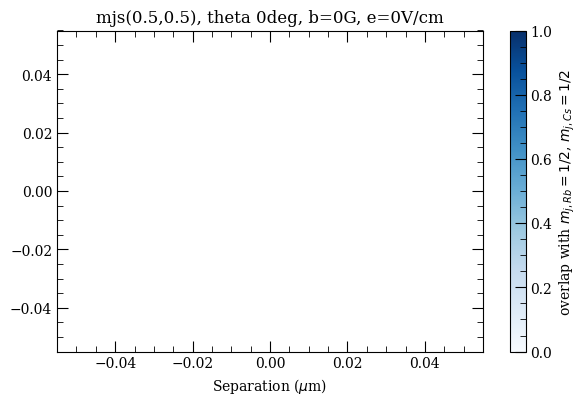

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


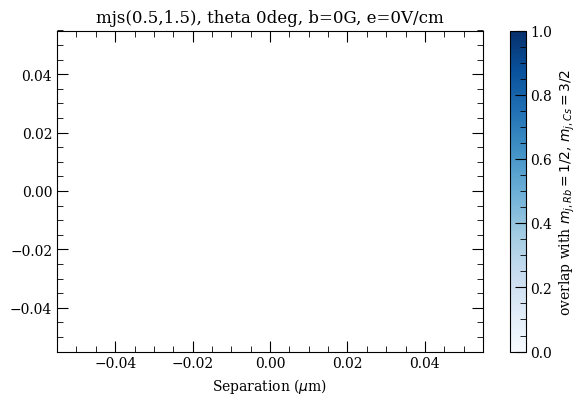

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


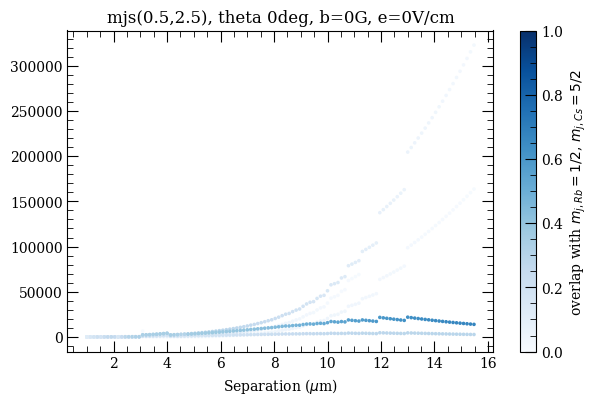

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


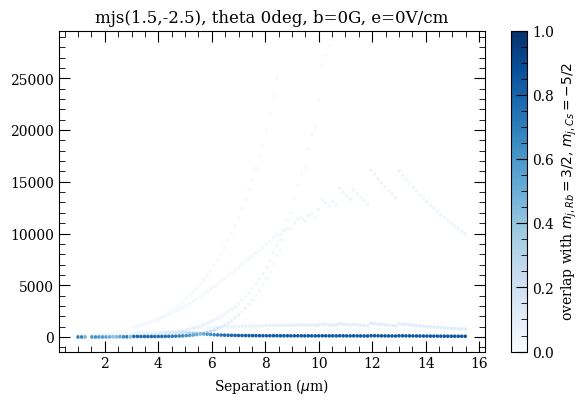

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


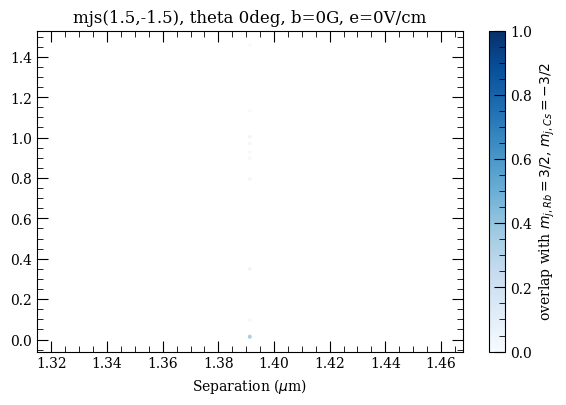

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


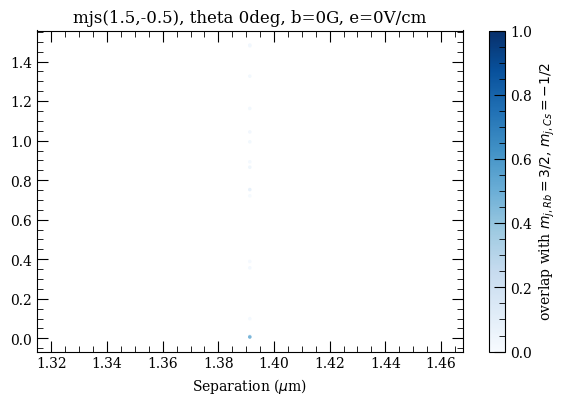

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


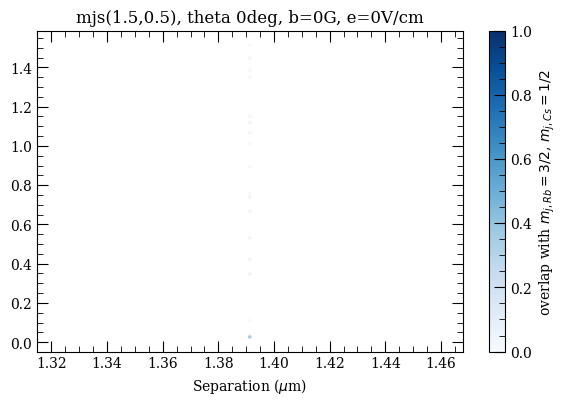

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


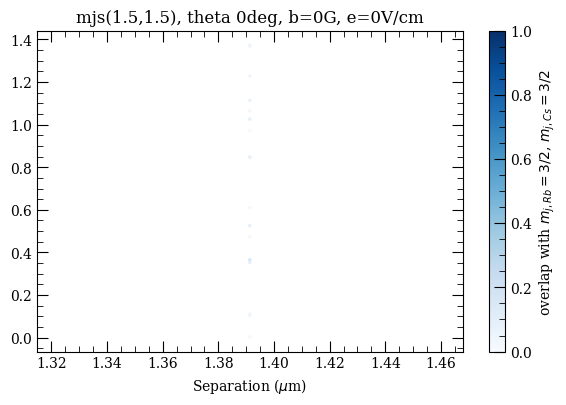

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


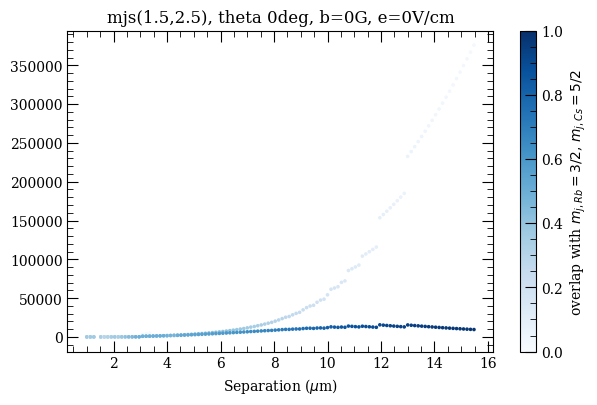

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


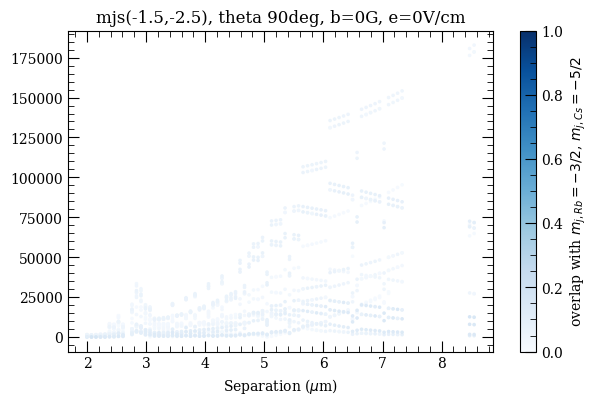

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


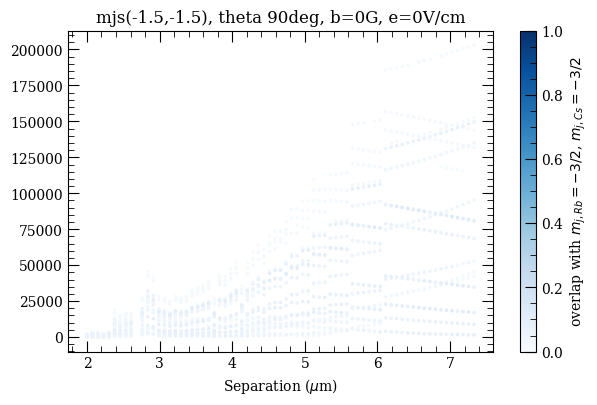

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


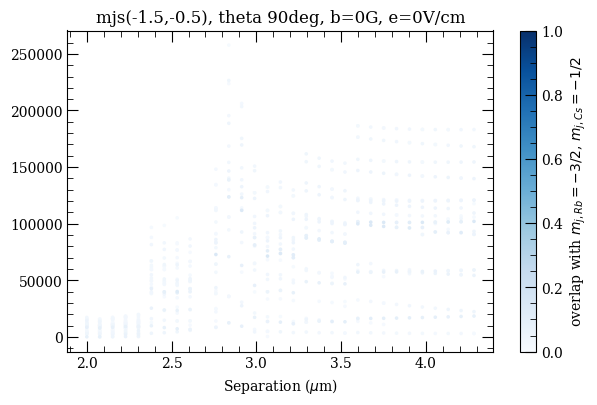

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


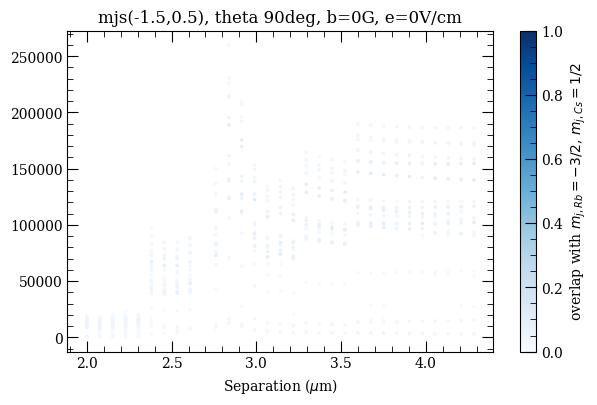

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


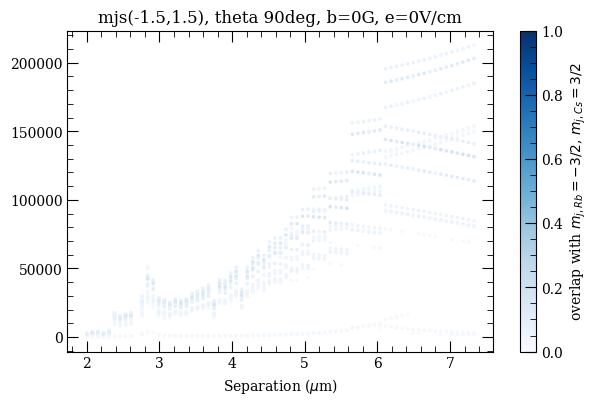

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


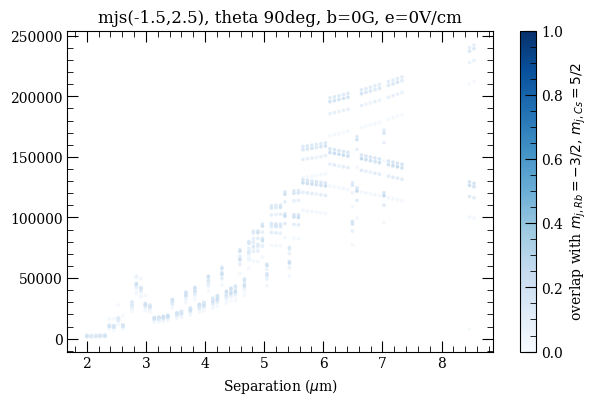

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


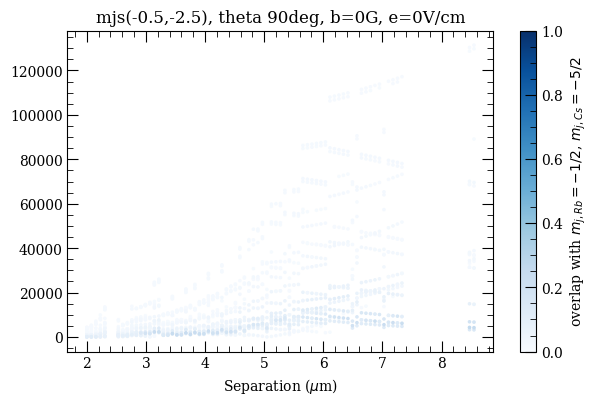

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


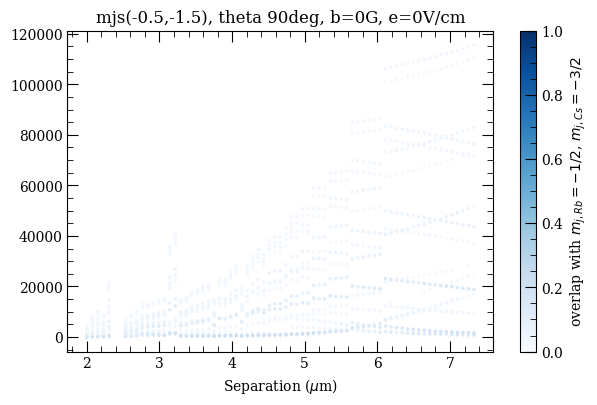

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


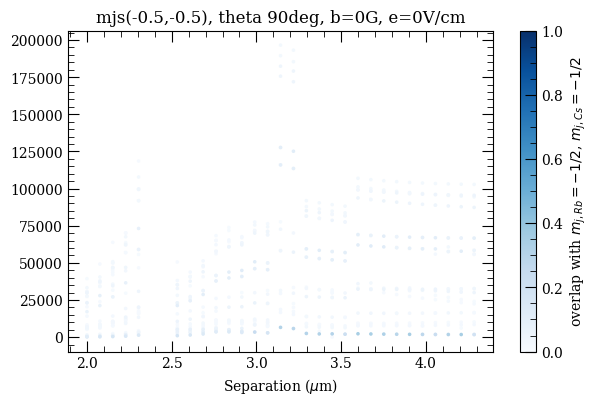

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


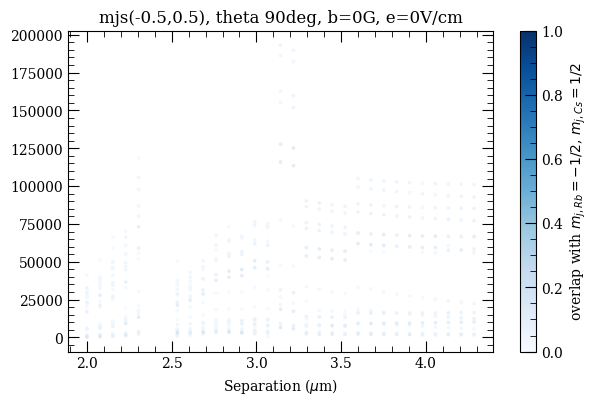

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


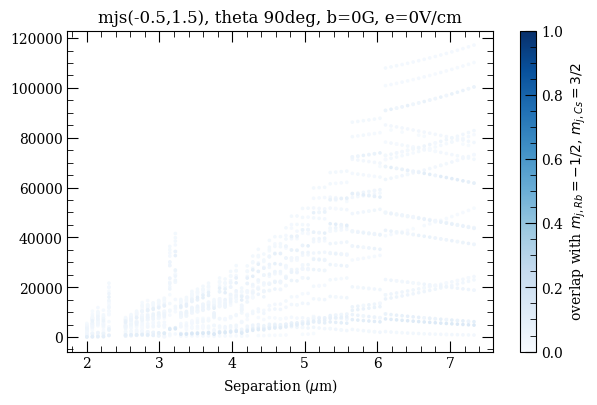

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


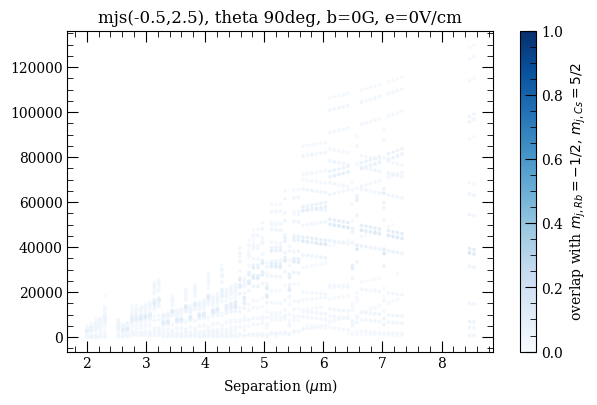

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


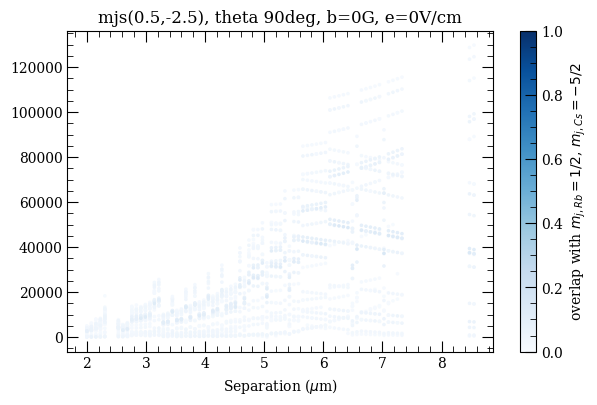

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


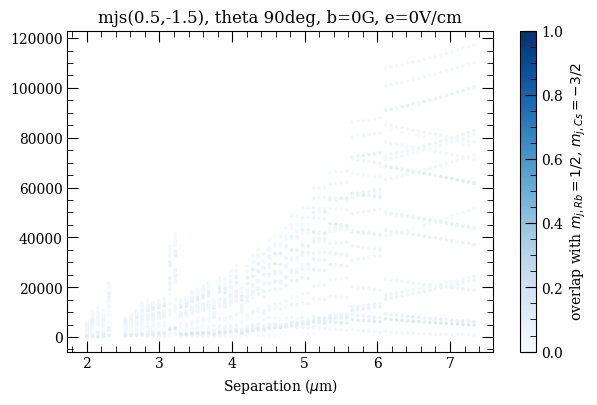

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


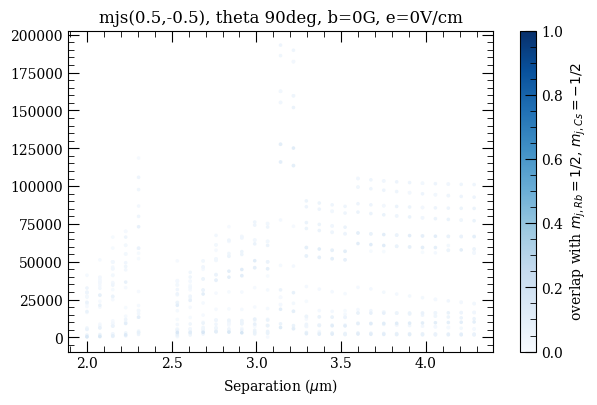

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


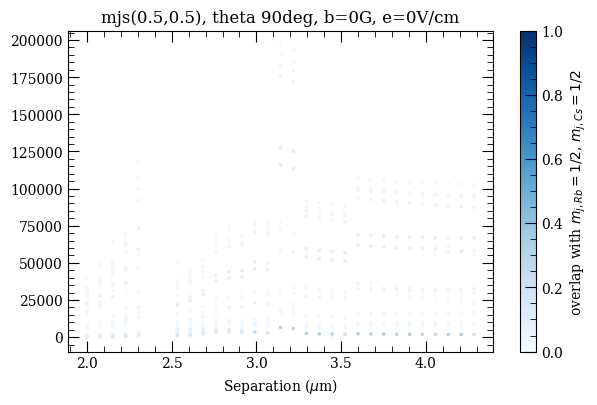

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


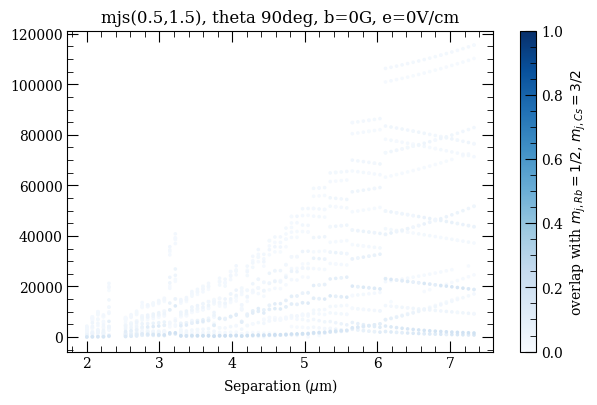

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


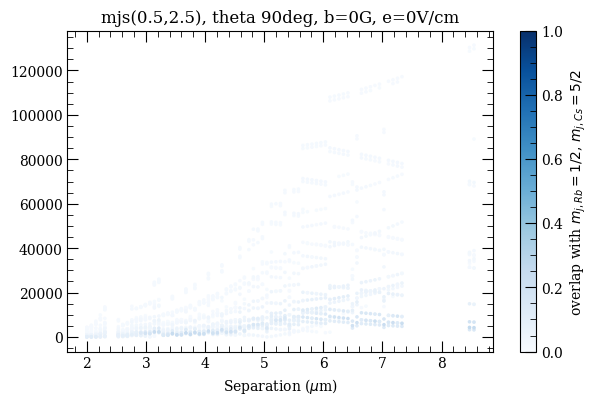

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


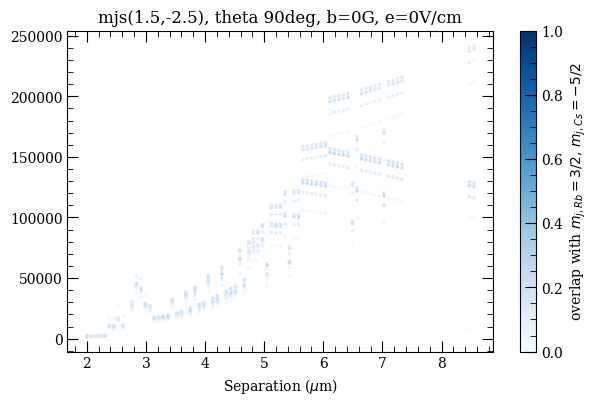

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


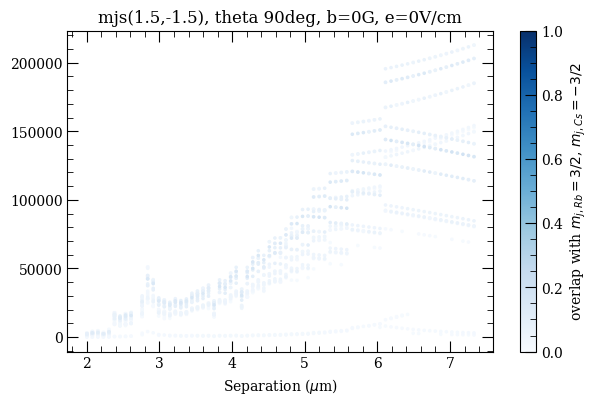

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


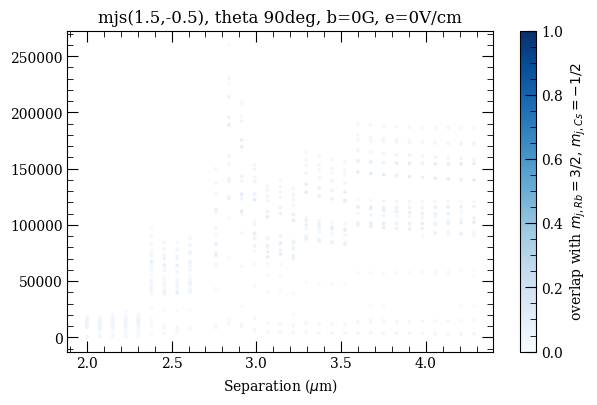

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


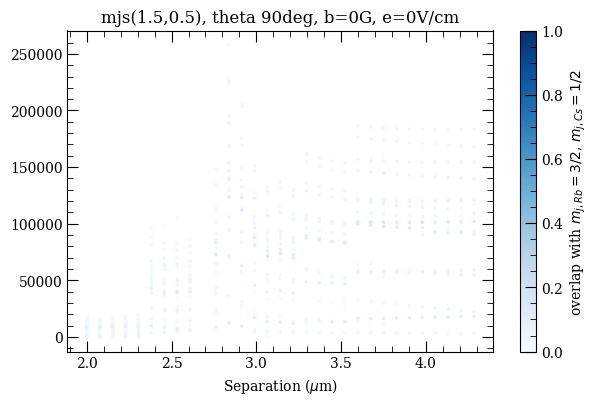

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


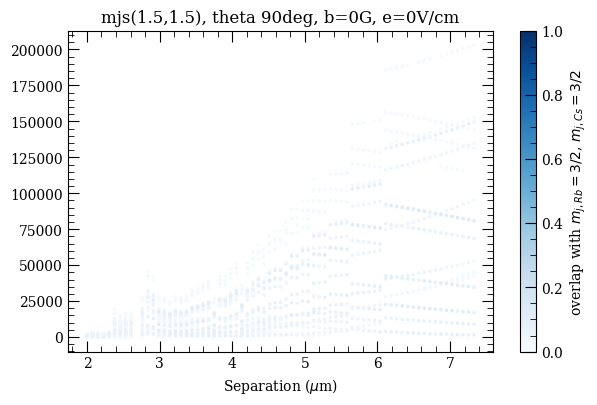

C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in sqrt
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)
C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\795640180.py:64: RuntimeWarning: invalid value encountered in scalar divide
  final_calc = current_energy/np.sqrt(val_big * val_third)


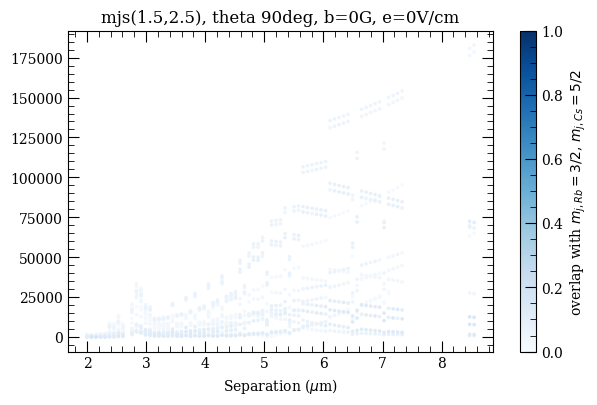

In [18]:
# assymetry parameter
import os
datapath_asym = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\asym\\'
if not os.path.exists(datapath_asym + 'inter'):
    os.makedirs(datapath_asym + 'inter')
if not os.path.exists(datapath_asym + 'intra Rb'):
    os.makedirs(datapath_asym + 'intra Rb')
if not os.path.exists(datapath_asym + 'intra Cs'):
    os.makedirs(datapath_asym + 'intra Cs')
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\assymetry\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)
# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']

# system_atom = system_atom_dict[efield]

thetas = [0, 90]
# b=bs[8]
for theta in thetas:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            # print(overlapped_inter)
            corrected_inter = pd.read_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {b}G.csv')
            corrected_intra_Rb = pd.read_csv(datapath_field + f'intra Rb\\mjs ({mj1}, {mj1}), theta {theta}, b {b}G.csv')
            corrected_intra_Cs = pd.read_csv(datapath_field + f'intra Cs\\mjs ({mj2}, {mj2}), theta {theta}, b {b}G.csv')
            # print(corrected_inter)
            # print(overlapped_inter_big['energy'])
            fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
          
            ax.set_xlabel(r"Separation ($\mu$m)")
            plt.tight_layout()
            plt.title(fr'mjs({mj1},{mj2}), theta {theta}deg, b={np.round(b,2)}G, e={e}V/cm')
            energy_lim = abs(100)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            # plt.ylim(0, max_energy)
            energies = {'energy' : [], 'r' : [], 'overlap' : []}

            big_lookup = dict(zip(corrected_intra_Rb['r'], corrected_intra_Rb['energy']))
            third_lookup = dict(zip(corrected_intra_Cs['r'], corrected_intra_Cs['energy']))

            # 2. Initialize your results (will be same length as the loop source)
            asym = {
            'energy': [],
            'r': [],
            'overlap': []
            }

            # 3. Iterate through EVERY element of the PRIMARY dataset
            for i, r in enumerate(corrected_inter['r']):
                current_energy = corrected_inter['energy'][i]
                # print(i)
                # Use .get(theta, 0) to "safely" grab the value. 
                # If the theta doesn't exist in that specific set, it defaults to 0.
                val_big = big_lookup.get(r, 0)
                val_third = third_lookup.get(r, 0)

                # 4. Perform your manipulation (e.g., subtracting both from the original)
                final_calc = current_energy/np.sqrt(val_big * val_third)

                # 5. Append to keep the output arrays aligned with the input
                asym['energy'].append(final_calc)
                asym['r'].append(r)
                asym['overlap'].append(corrected_inter['overlap'][i])
                    
                    
                    

            # print(energies['energy']-overlapped_inter['energy'])

            scat = plt.scatter(
                asym['r'],
                abs(np.array(asym['energy'])),
                c=asym['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Blues'
            )

            pd.DataFrame(asym).to_csv(datapath_asym + f'\\mjs ({mj1}, {mj2}), theta {theta}deg, b {np.round(b,3)}G.csv')
            plt.colorbar(label = fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$')
            plt.show()
            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            fig.savefig(figpath + f'sep {r}um b{np.round(b,3)}G e{e}Vcm mjs{mj1},{mj2}.png', bbox_inches = 'tight')
            plt.close()


C:\Users\tommy\AppData\Local\Temp\ipykernel_21404\3335556044.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = plt.legend()


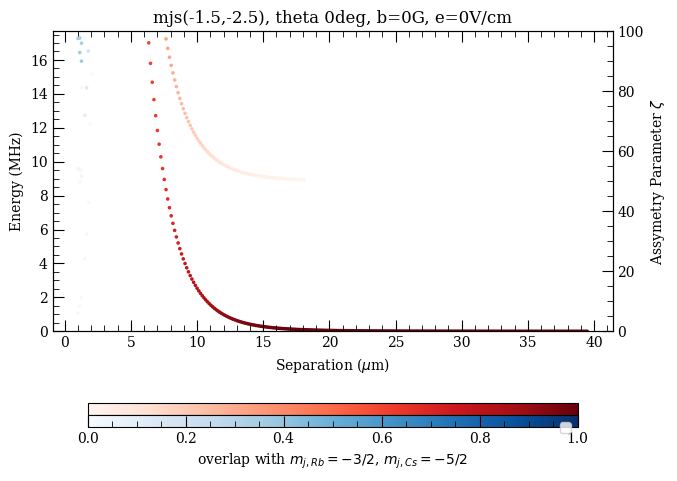

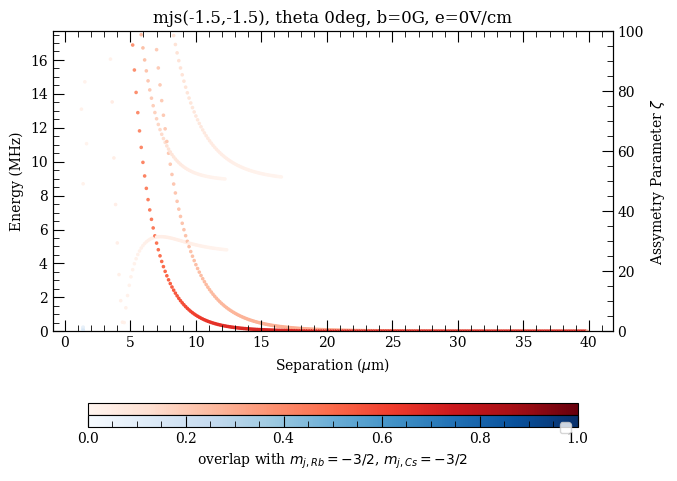

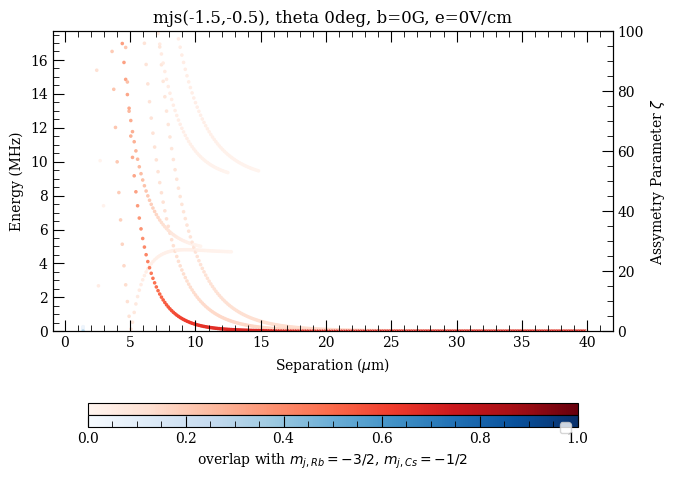

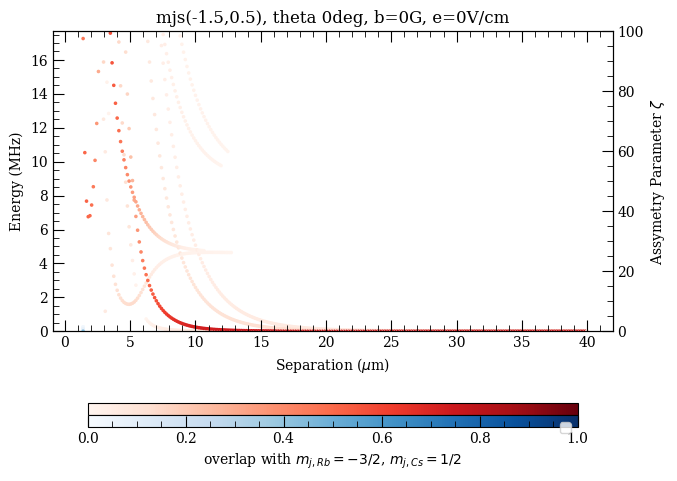

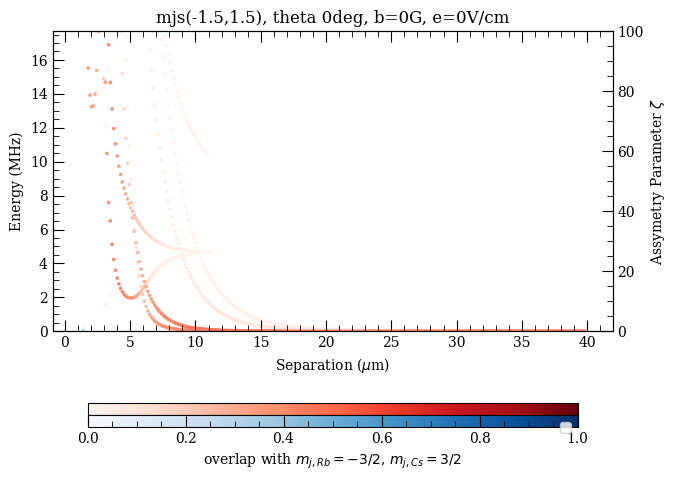

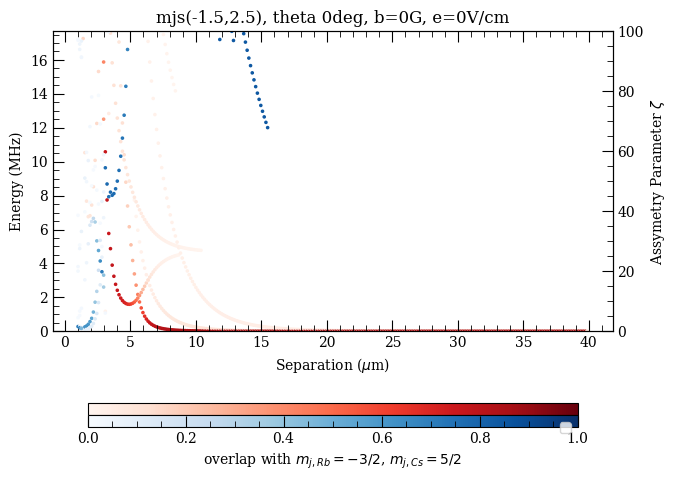

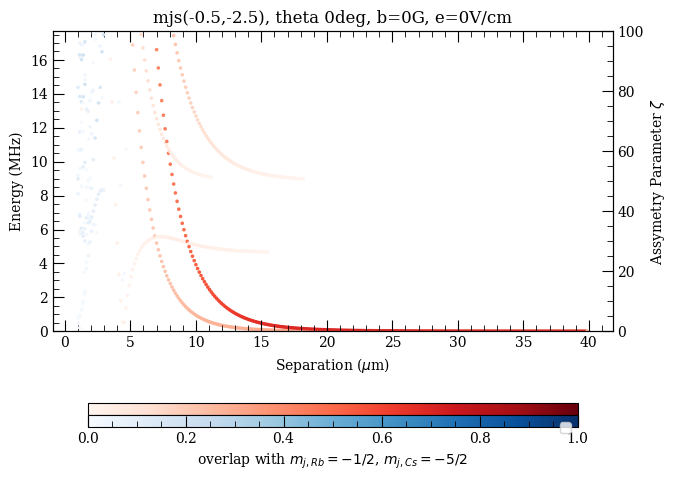

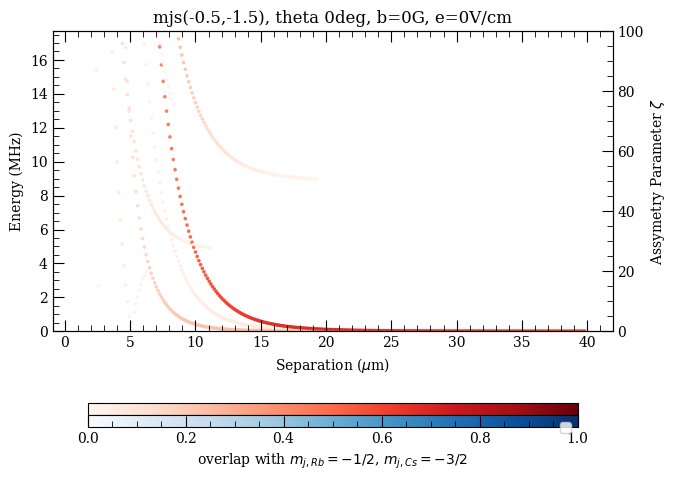

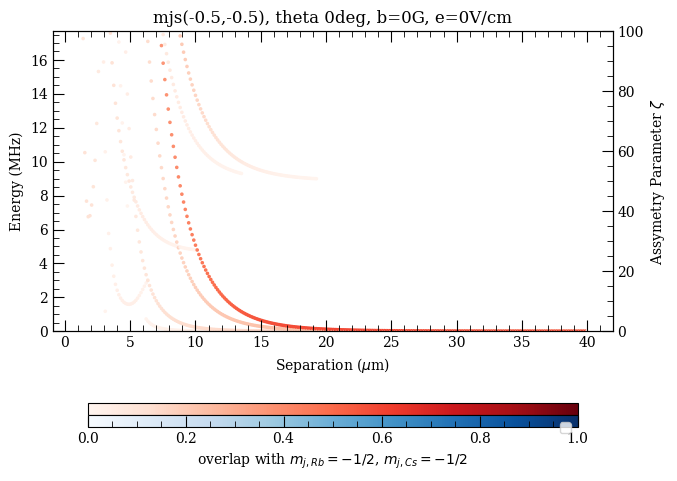

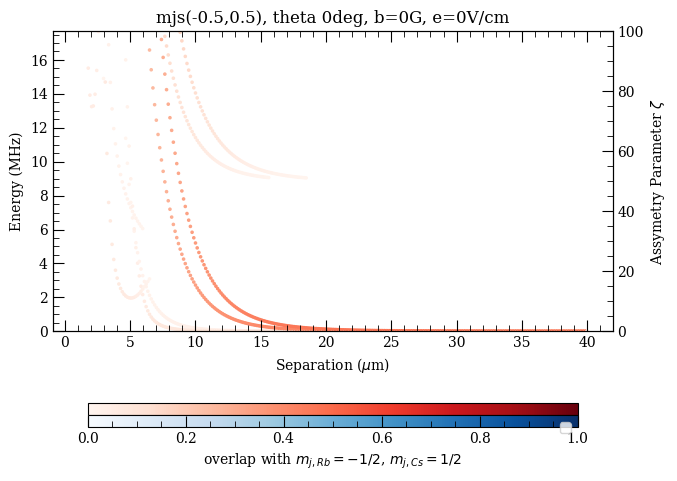

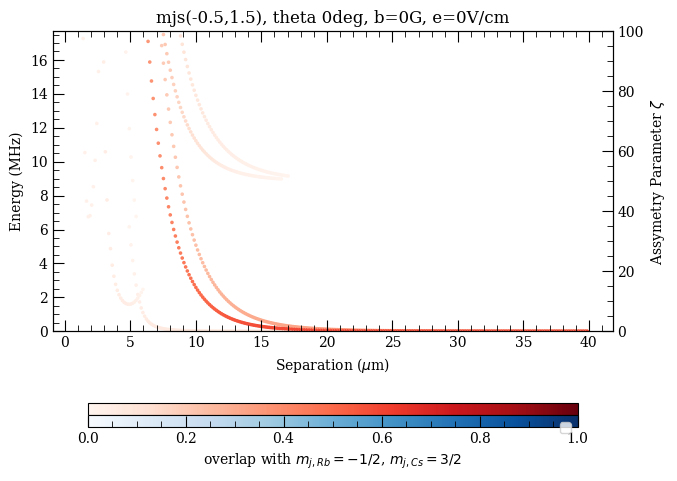

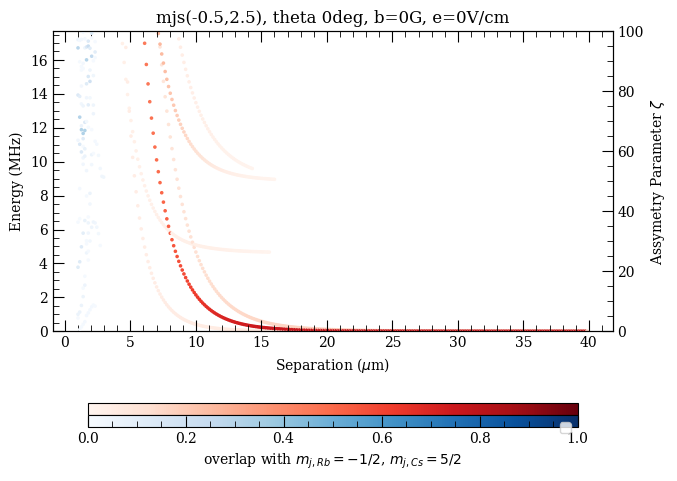

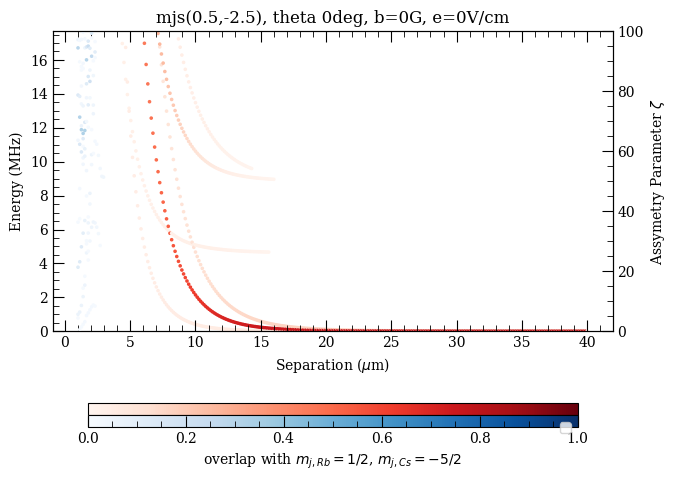

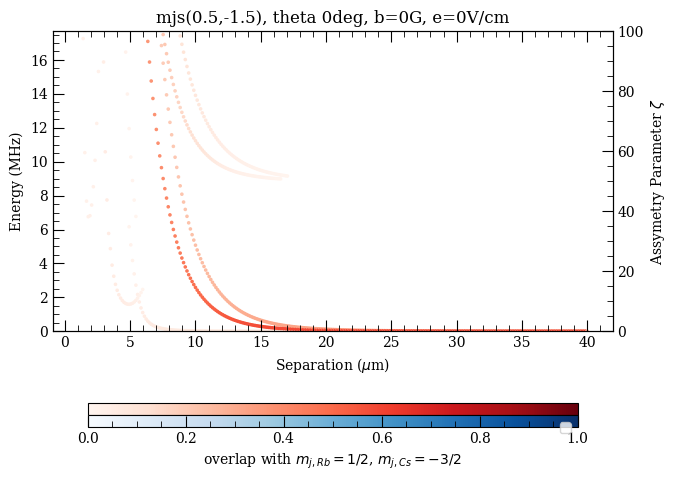

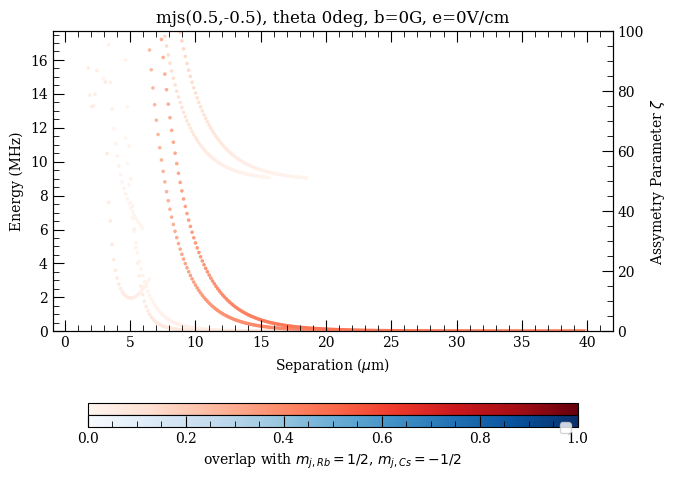

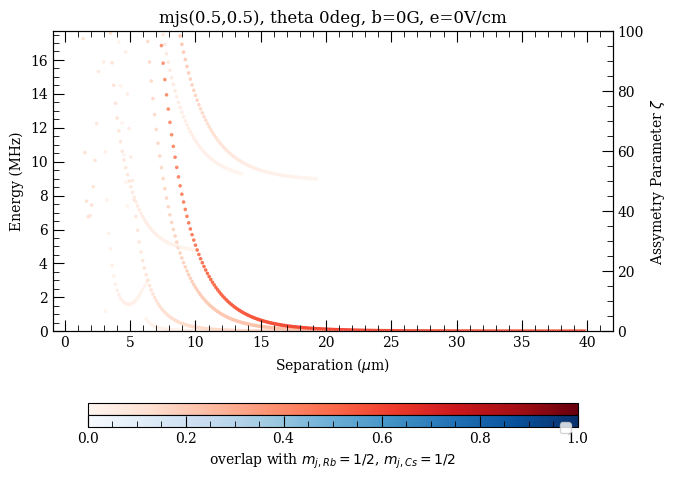

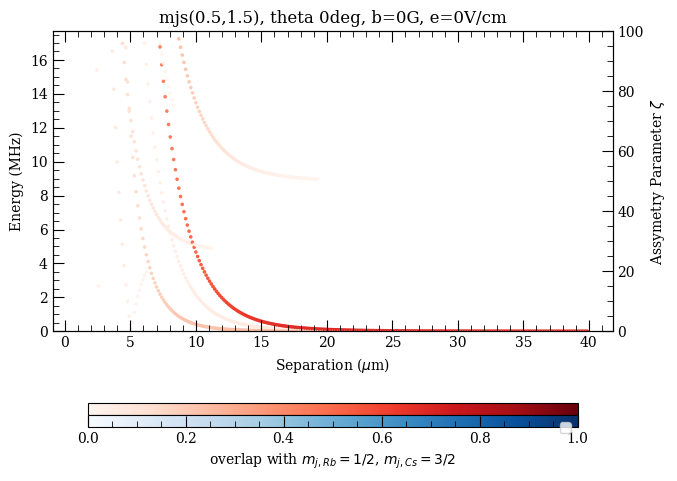

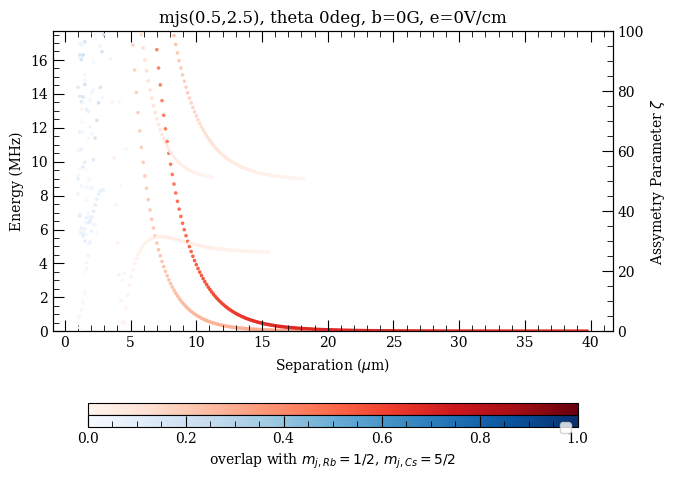

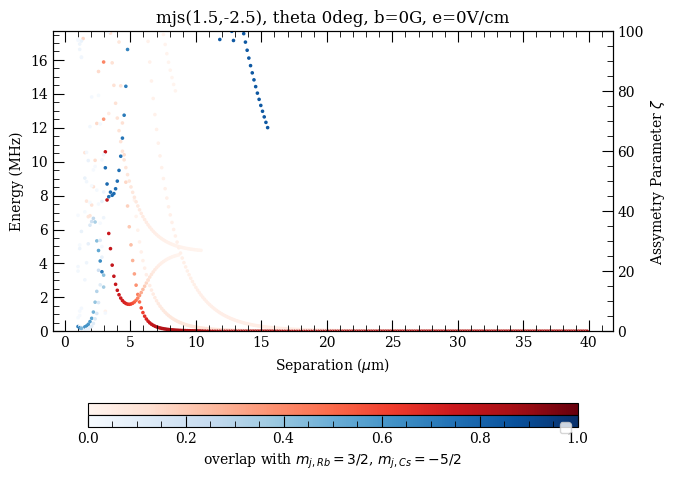

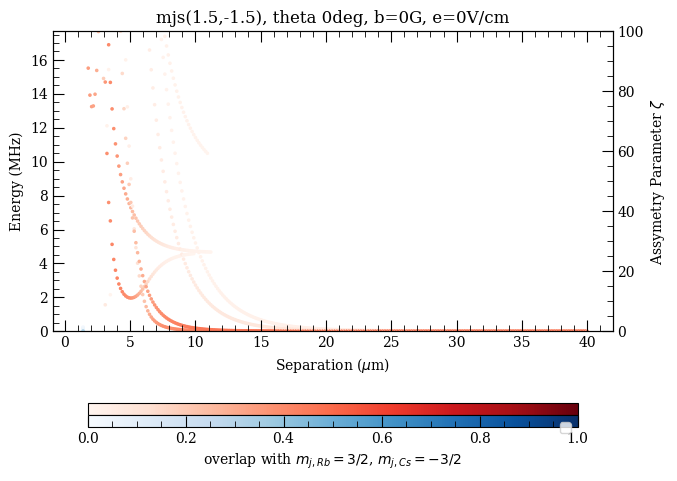

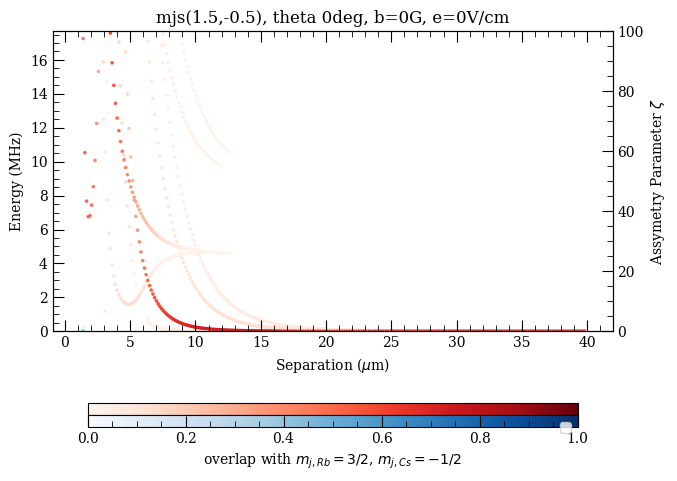

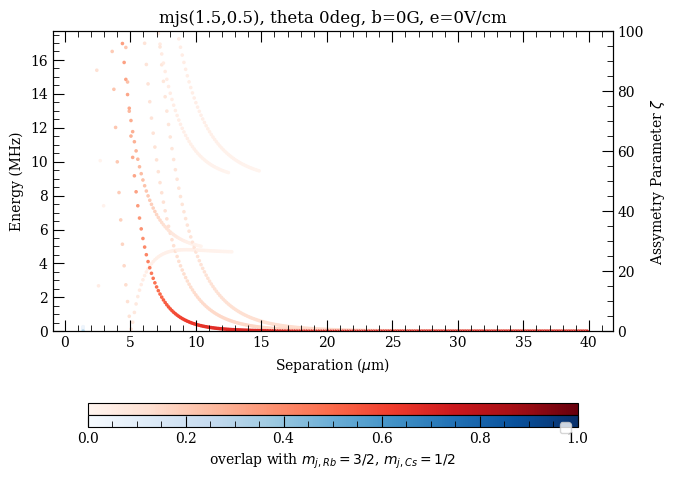

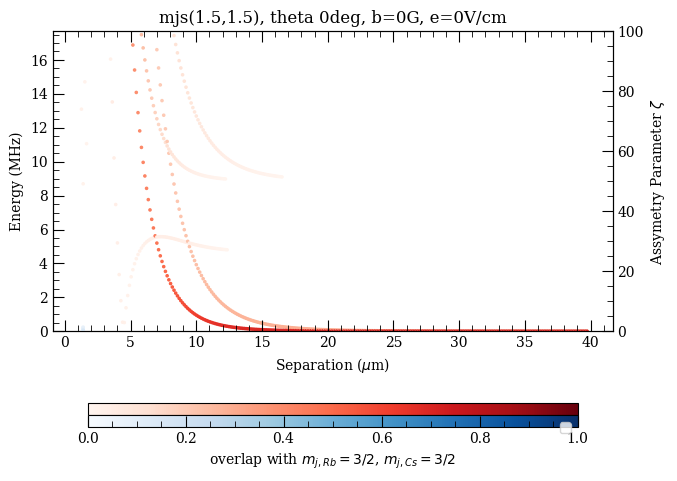

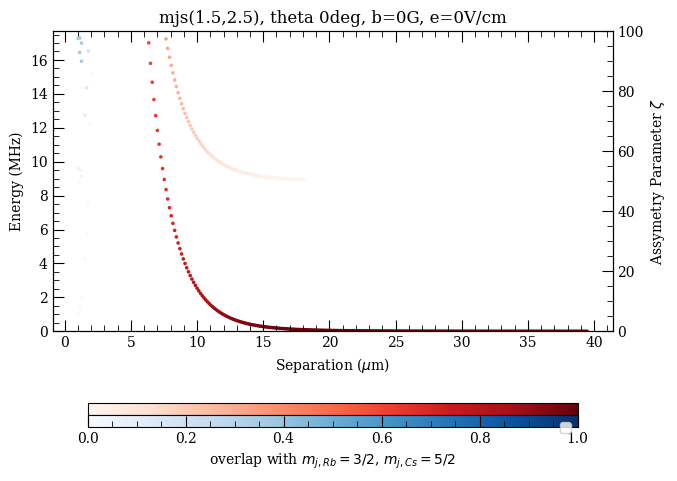

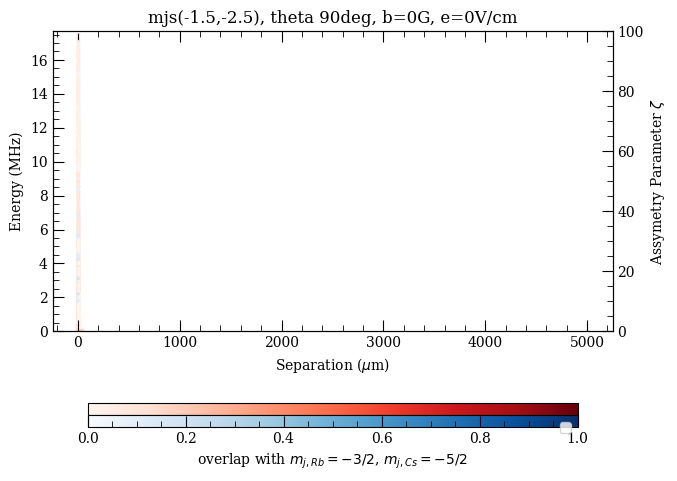

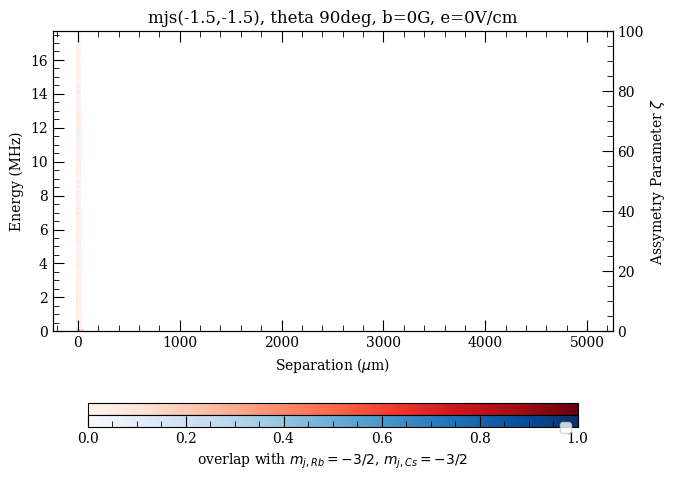

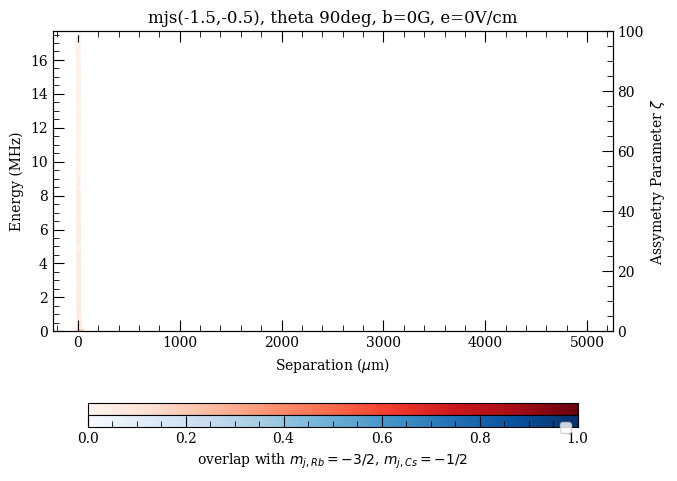

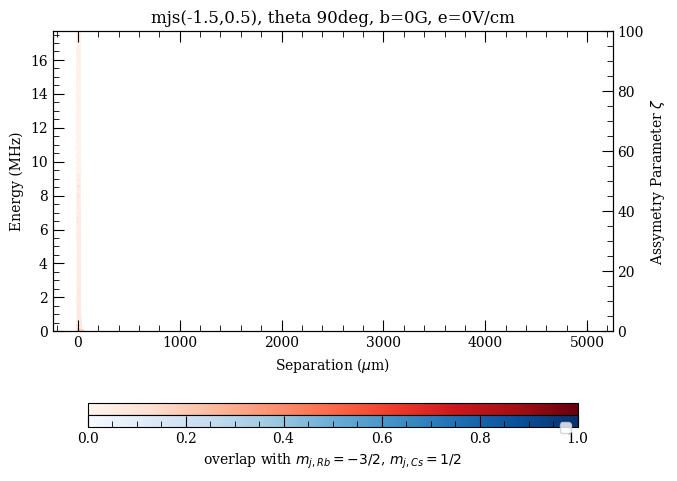

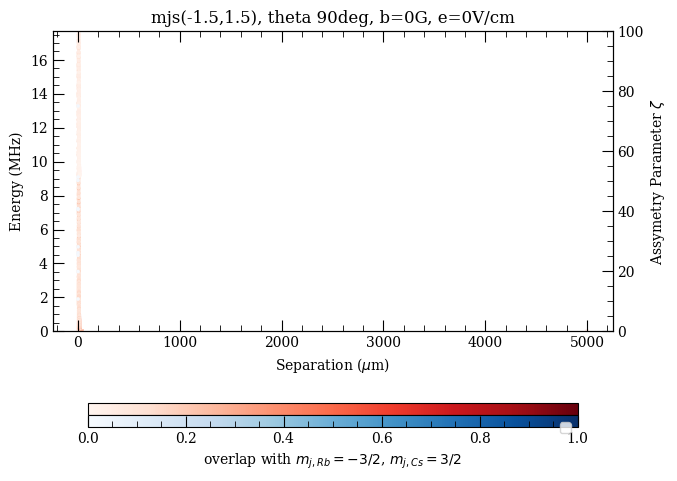

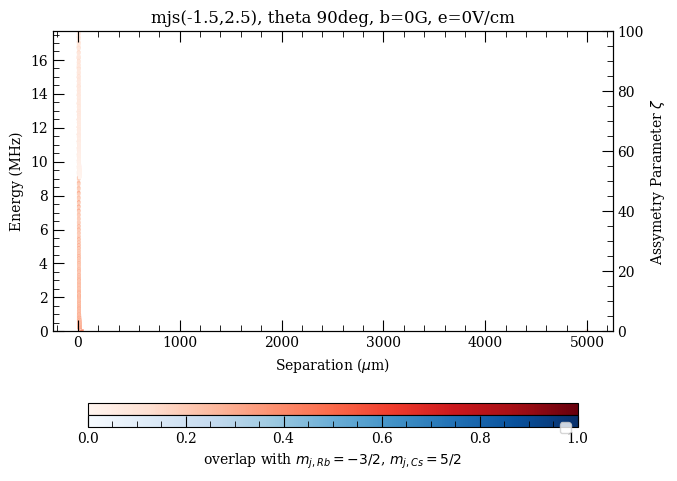

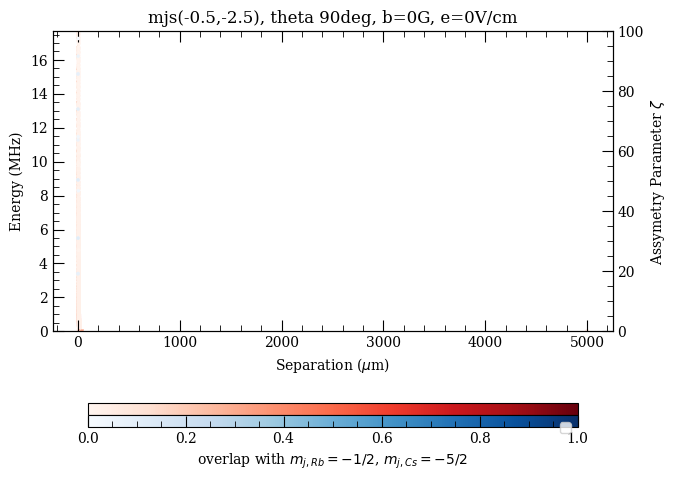

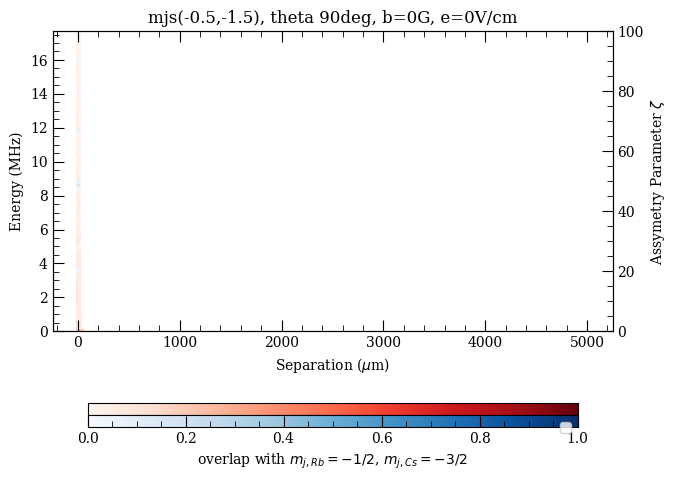

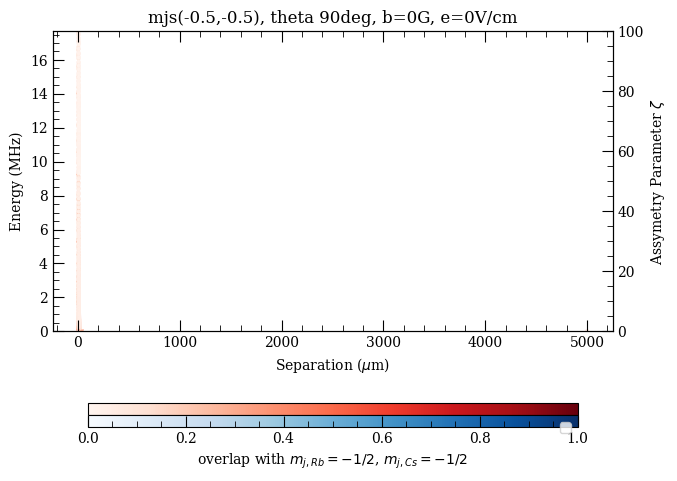

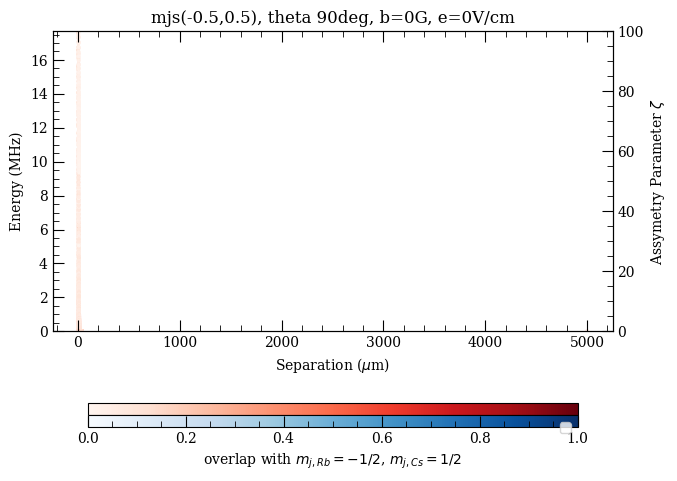

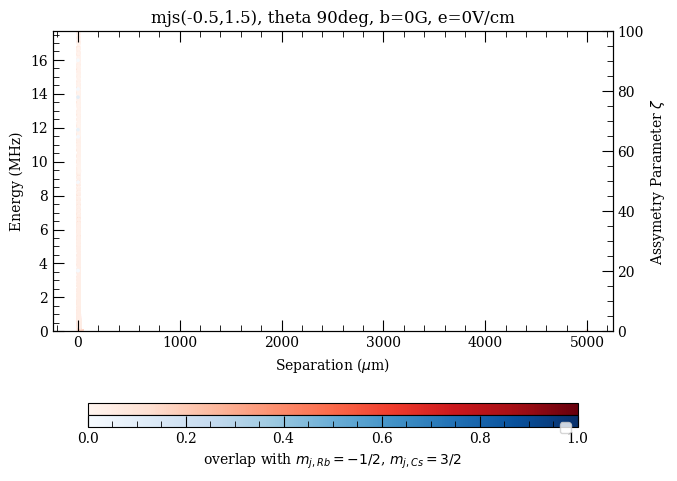

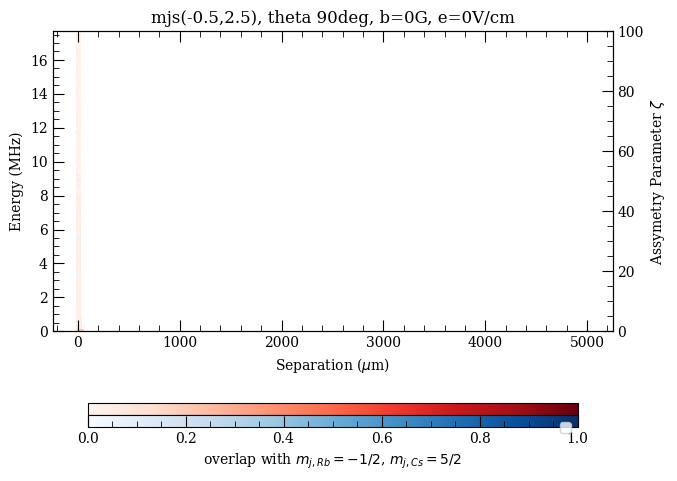

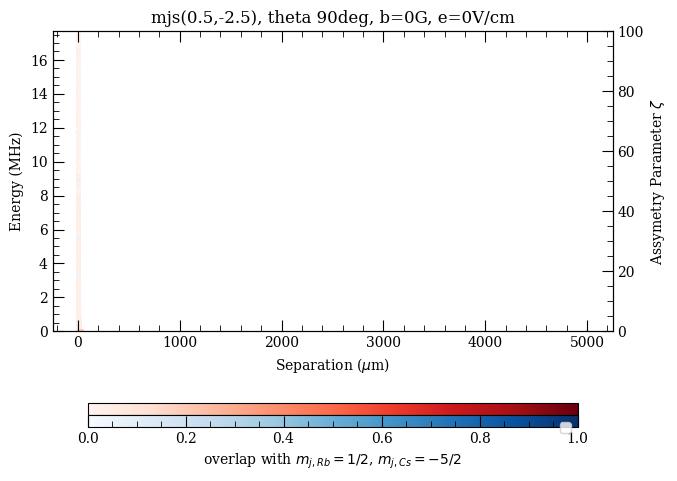

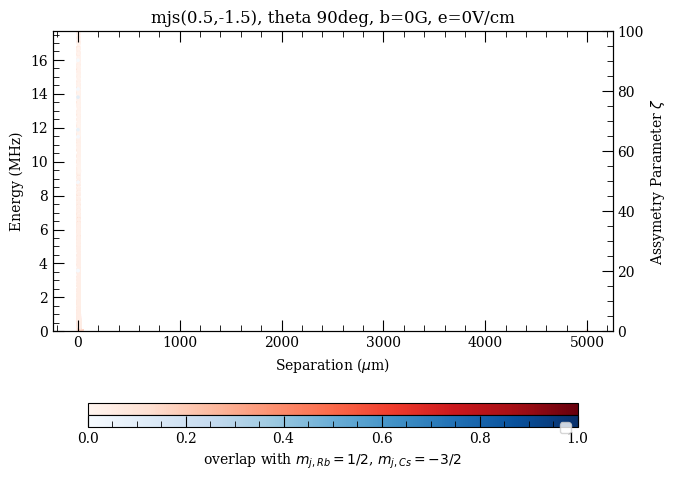

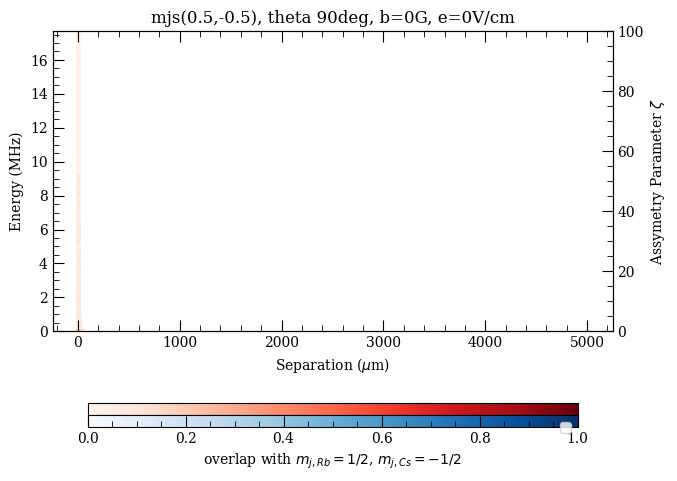

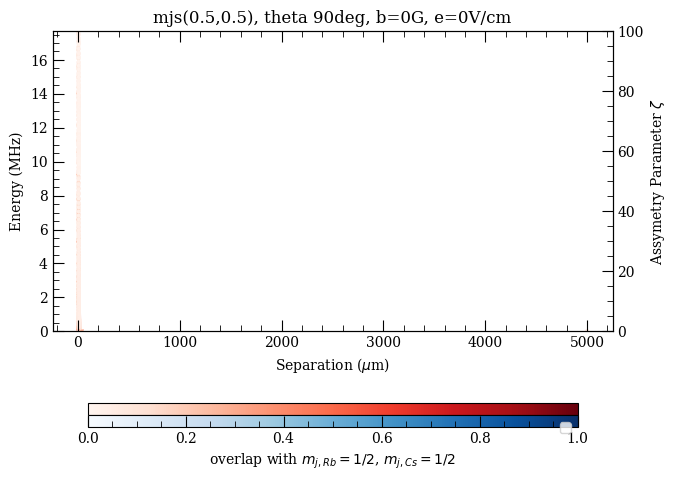

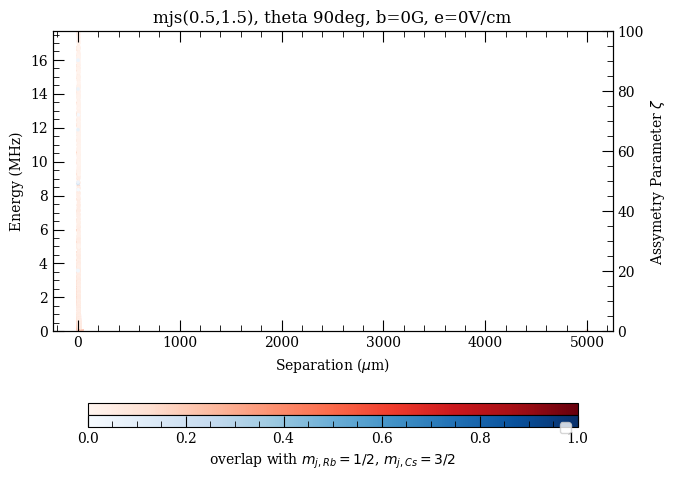

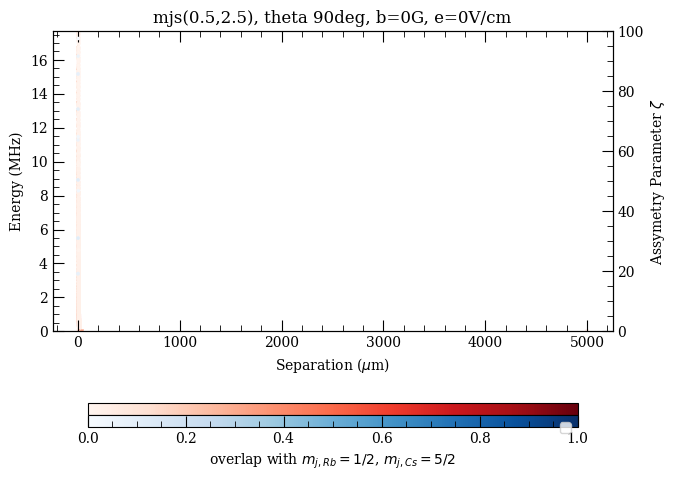

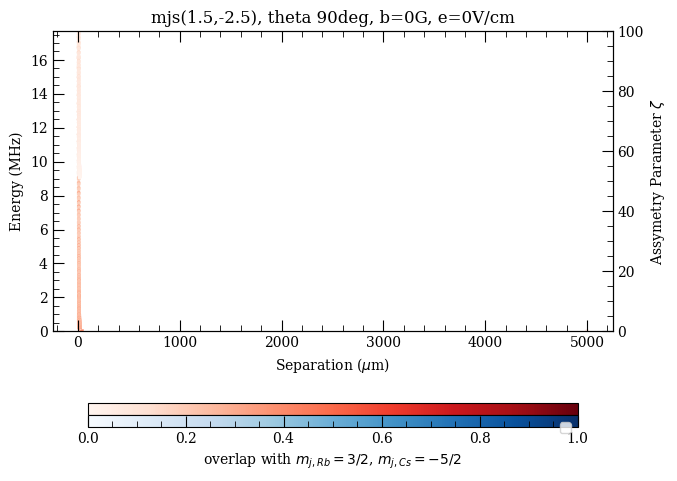

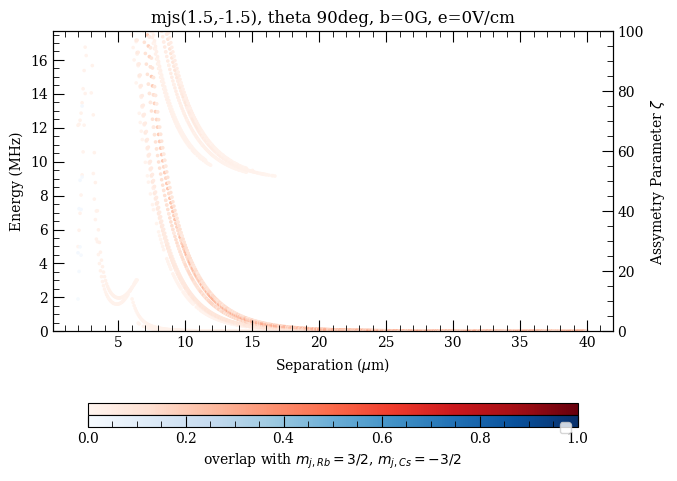

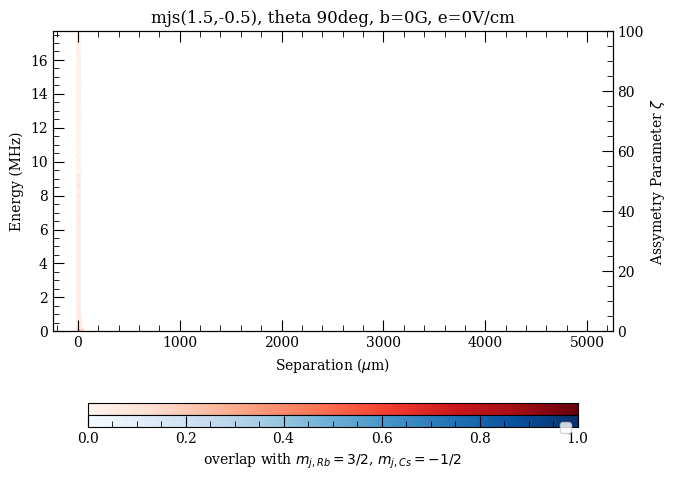

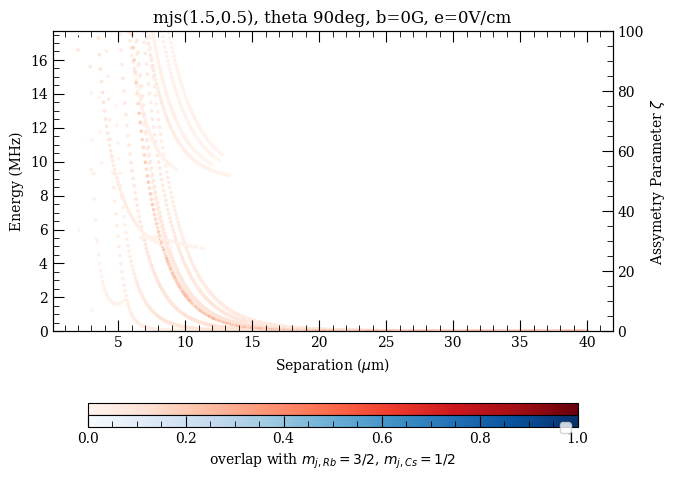

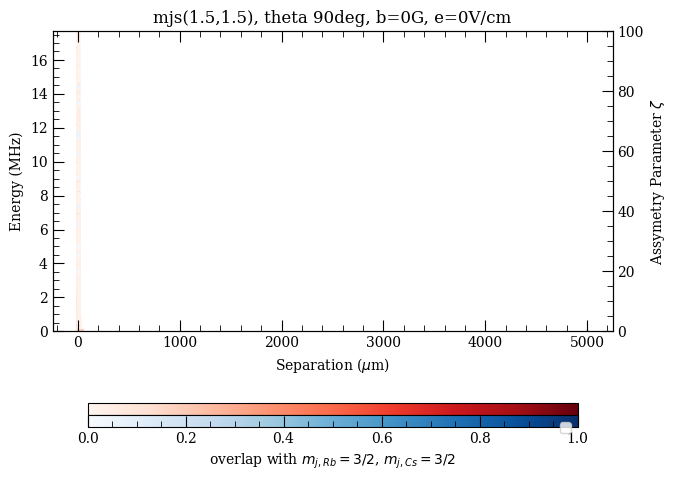

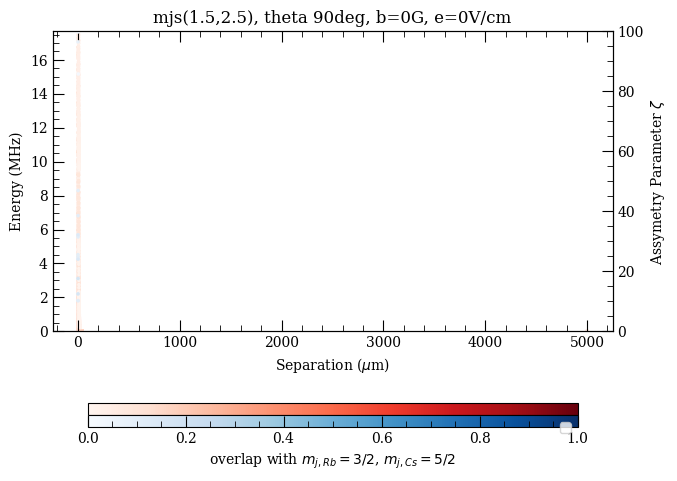

In [19]:
# both plotted together
import os
datapath_asym = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\asym\\'

datapath_field = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\field-corrected\\'

import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\dual plots\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)
# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']
theta=0
# system_atom = system_atom_dict[efield]
for theta in thetas:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            # print(overlapped_inter)
            corrected_inter = pd.read_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {b}G.csv')
            assym = pd.read_csv(datapath_asym + f'\\mjs ({mj1}, {mj2}), theta {theta}deg, b {np.round(b,3)}G.csv')
            # print(corrected_inter)
            # print(overlapped_inter_big['energy'])
            fig, ax = plt.subplots(1, 1, figsize=(7, 4))
          
            ax.set_xlabel(r"Separation ($\mu$m)")
            plt.tight_layout()
            ax.set_title(fr'mjs({mj1},{mj2}), theta {theta}deg, b={np.round(b,2)}G, e={e}V/cm')
            energy_lim = abs(20)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            plt.ylim(0, max_energy)

            # print(energies['energy']-overlapped_inter['energy'])

            ax.set_ylabel(f"Energy ({energy_unit})")  # Label for the first y-axis
            ax1 = ax.twinx()  # Create a second y-axis
            ax1.set_ylabel(r'Assymetry Parameter $\zeta$')  # Label
            scat_assym = ax1.scatter(
                assym['r'],
                abs(np.array(assym['energy'])),
                c=assym['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                label = r'$\zeta$',
                cmap = 'Blues'
            )
            
            scat_energy = ax.scatter(
                corrected_inter['r'],
                abs(np.array(corrected_inter['energy'])),
                c=corrected_inter['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Reds',
                label = r'$\Delta E$'
            )
            # plt.colorbar(scat, cax=cbar_ax, orientation='horizontal', label = fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$')
            
            plt.subplots_adjust(left=0.1, right=0.9, top=1, bottom=.25, wspace=0.4, hspace=.4)

            cax1 = fig.add_axes([0.15, 0.04, 0.7, 0.03]) 
            cax2 = fig.add_axes([0.15, 0.01, 0.7, 0.03])

            fig.colorbar(scat_energy, cax=cax1, orientation='horizontal', ticks=[])
            fig.colorbar(scat_assym, cax=cax2, orientation='horizontal', label=fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$')
            leg = plt.legend()
            for lh in leg.legend_handles:
                if lh is not None:  # Use 'is not None' instead of 'if lh:'
                    lh.set_alpha(1)
            # ax.set_ylim(0, max_energy)
            # ax.set_yscale('log')
            ax1.set_ylim(0, 100)
            # pd.DataFrame(assym).to_csv(datapath_assym + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {b}G.csv')
            # plt.colorbar(scat, cax=cbar_ax, orientation='horizontal', label = fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$')
            # plt.colorbar(label = fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$', location='bottom')
            plt.show()
            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            fig.savefig(figpath + f'theta {theta}deg b{np.round(b,3)}G e{e}Vcm mjs{mj1},{mj2}.png', bbox_inches = 'tight')
            plt.close()


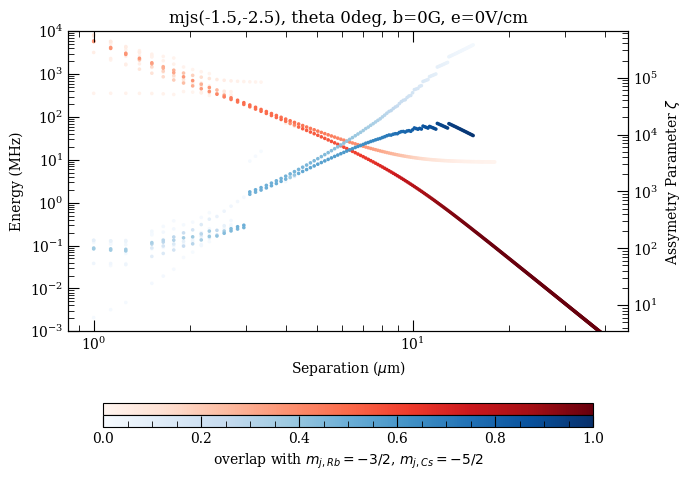

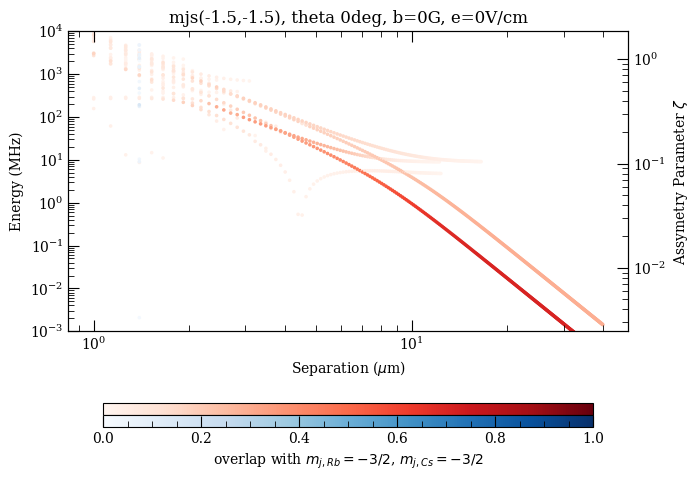

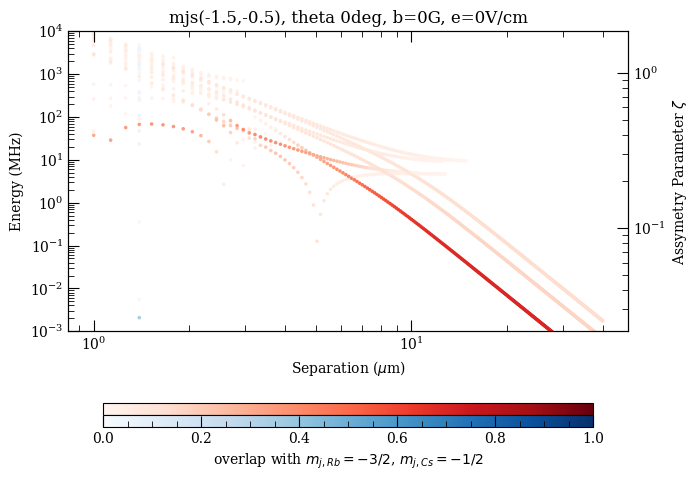

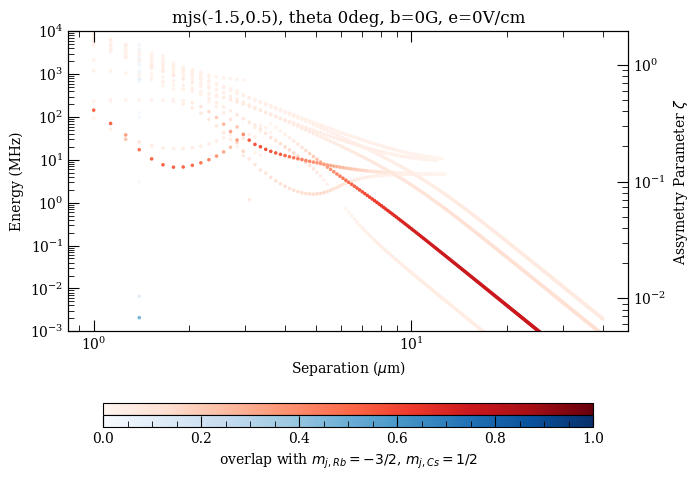

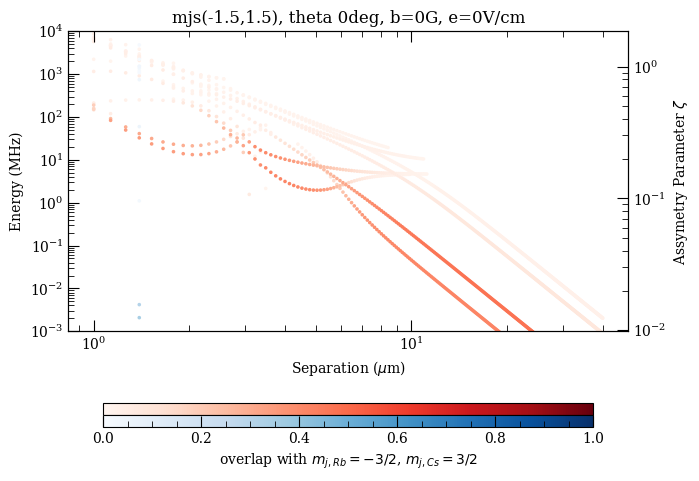

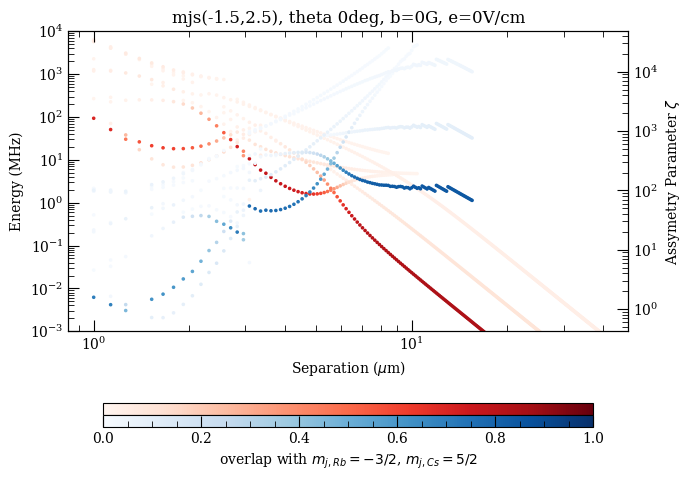

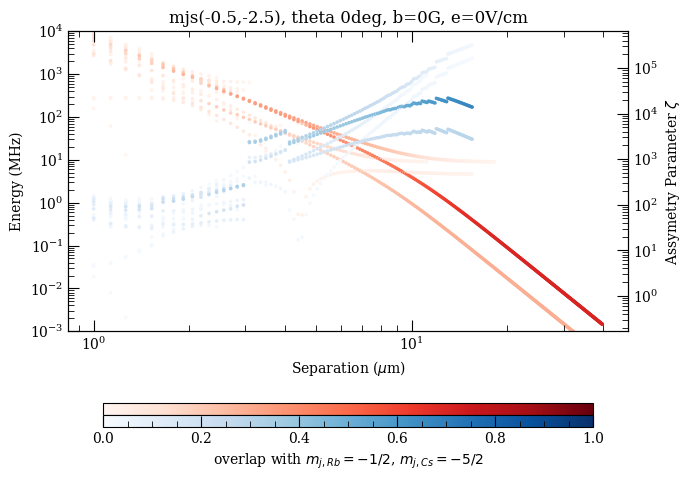

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 700x400 with 4 Axes>

ValueError: Data has no positive values, and therefore cannot be log-scaled.

In [21]:
# both plotted together log scale
import os
datapath_asym = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\asym\\'

datapath_field = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\field-corrected\\'

fitted_datapath =fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\field-corrected\\fitted\\'

import os
figpath_log = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\dual plots\\log scale\\'
if not os.path.exists(figpath_log):
    os.makedirs(figpath_log)
# ax.set_ylim(-0.01, 0.01)
theta=0
prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']
# theta=0
# system_atom = system_atom_dict[efield]
b=bs[0]
for theta in thetas:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            # print(overlapped_inter)
            corrected_inter = pd.read_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {b}G.csv')
            assym = pd.read_csv(datapath_asym + f'\\mjs ({mj1}, {mj2}), theta {theta}deg, b {np.round(b,3)}G.csv')
            
            # print(corrected_inter)
            # print(overlapped_inter_big['energy'])
            fig, ax = plt.subplots(1, 1, figsize=(7, 4))
          
            ax.set_xlabel(r"Separation ($\mu$m)")
            plt.tight_layout()
            ax.set_title(fr'mjs({mj1},{mj2}), theta {theta}deg, b={np.round(b,2)}G, e={e}V/cm')
            energy_lim = abs(20)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            # plt.ylim(0, max_energy)
            
            # print(energies['energy']-overlapped_inter['energy'])
            if os.path.exists(fitted_datapath + f'mjs ({mj1}, {mj2}), theta {theta}, b {b}G.csv'):
                print('fitted')
                fitted = pd.read_csv(fitted_datapath + f'mjs ({mj1}, {mj2}), theta {theta}, b {b}G.csv')
                ax.plot(fitted['rs'], fitted['energy'], c='0', linewidth = 2, linestyle = 'dashed')
            ax.set_ylabel(f"Energy ({energy_unit})")  # Label for the first y-axis
            ax1 = ax.twinx()  # Create a second y-axis
            ax1.set_ylabel(r'Assymetry Parameter $\zeta$')  # Label
            scat_assym = ax1.scatter(
                assym['r'],
                abs(np.array(assym['energy'])),
                c=assym['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                label = r'$\zeta$',
                cmap = 'Blues'
            )
            # ax1.set_yscale('log')
            
            scat_energy = ax.scatter(
                corrected_inter['r'],
                abs(np.array(corrected_inter['energy'])),
                c=corrected_inter['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Reds',
                label = r'$\Delta E$'
            )
            ax.set_yscale('log')
            ax1.set_yscale('log')
            # plt.colorbar(scat, cax=cbar_ax, orientation='horizontal', label = fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$')
            ax.set_ylim([10**-3, 10**4])
            plt.subplots_adjust(left=0.1, right=0.9, top=1, bottom=.25, wspace=0.4, hspace=.4)

            cax1 = fig.add_axes([0.15, 0.04, 0.7, 0.03]) 
            cax2 = fig.add_axes([0.15, 0.01, 0.7, 0.03])
            # leg = ax.legend(handles = (scat_energy, scat_assym))
            # for lh in leg.legend_handles:
            #     if lh is not None:  # Use 'is not None' instead of 'if lh:'
            #         lh.set_alpha(1)
            fig.colorbar(scat_energy, cax=cax1, orientation='horizontal', ticks=[])
            fig.colorbar(scat_assym, cax=cax2, orientation='horizontal', label=fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$')
            
            # ax.set_ylim(0, max_energy)
            # ax1.set_ylim(0, 100000)
            ax.set_xscale('log')
            # pd.DataFrame(assym).to_csv(datapath_assym + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {b}G.csv')
            # plt.colorbar(scat, cax=cbar_ax, orientation='horizontal', label = fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$')
            # plt.colorbar(label = fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$', location='bottom')
            plt.show()
            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            fig.savefig(figpath_log + f'theta {theta}deg b{np.round(b,4)}G e{e}Vcm mjs{mj1},{mj2}.png', bbox_inches = 'tight')
            plt.close()
